# Neural Networks (sklearn)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [2]:
# Load the data
data = pd.read_csv('../dataset/cmi_internet_cleaned.csv')
X = data.drop(columns=['sii'])
y = data['sii']

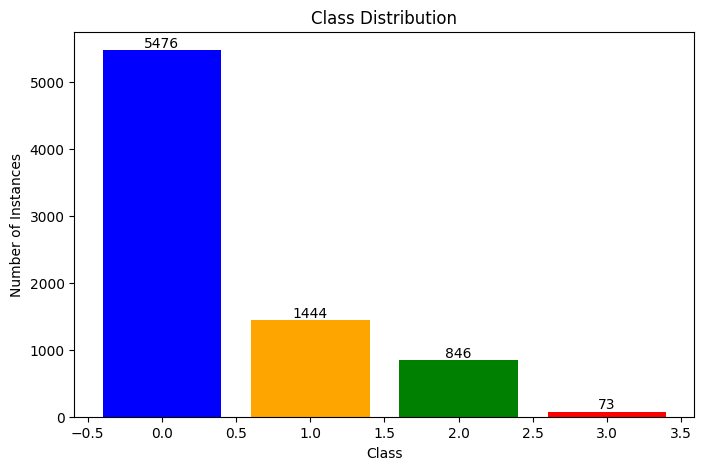

In [3]:
# plot class distribution with number of instances above each bar
class_counts = y.value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.title('Class Distribution')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha='center', va='bottom')
plt.show()


In [4]:
# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Multiclass Problem

In [6]:
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import log_loss
from evaluate_classifier import evaluate_classifier


## A) **Perceptron**


In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler, ADASYN

# Setup: 5-fold Stratified Cross-Validation 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics definition
scoring_metrics = ['balanced_accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

# Three pipelines to compare: Original, ROS, and ADASYN
pipelines = {
    "Perceptron (Original)": Perceptron(penalty="l2", random_state=42, class_weight=None),
    
    "Perceptron + ROS": make_pipeline(
        RandomOverSampler(random_state=42), 
        Perceptron(penalty="l2", random_state=42)
    ),
    
    "Perceptron + ADASYN": make_pipeline(
        ADASYN(random_state=42, n_neighbors=5), 
        Perceptron(penalty="l2", random_state=42)
    )
}

# Dictionary to store the results of cross-validation for each pipeline
cv_results_summary = {}

print("Computing Cross-Validation...\n")

for name, pipeline in pipelines.items():
    print(f"Running {name}...")
    # cross-validation on the original dataset (X_train, y_train)
    # This will give us the performance metrics for each fold, 
    # which we can then summarize
    scores = cross_validate(
        pipeline, X_train, y_train, # pipeline defines (1) the model and (2) the resampling strategy 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Compute mean and std for each metric and store in the summary dictionary
    cv_results_summary[name] = {
        "Balanced Accuracy": f"{scores['test_balanced_accuracy'].mean():.4f} (± {scores['test_balanced_accuracy'].std():.3f})",
        "F1 Macro": f"{scores['test_f1_macro'].mean():.4f} (± {scores['test_f1_macro'].std():.3f})",
        "Precision Macro": f"{scores['test_precision_macro'].mean():.4f} (± {scores['test_precision_macro'].std():.3f})",
        "Recall Macro": f"{scores['test_recall_macro'].mean():.4f} (± {scores['test_recall_macro'].std():.3f})"
    }

# Create a DataFrame from the results summary for better visualization
df_results = pd.DataFrame(cv_results_summary).T
display(df_results)

Computing Cross-Validation...

Running Perceptron (Original)...
Running Perceptron + ROS...
Running Perceptron + ADASYN...


,Balanced Accuracy,F1 Macro,Precision Macro,Recall Macro
Perceptron (Original),0.2862 (± 0.026),0.2784 (± 0.019),0.2881 (± 0.025),0.2862 (± 0.026)
Perceptron + ROS,0.2999 (± 0.036),0.2328 (± 0.020),0.2756 (± 0.014),0.2999 (± 0.036)
Perceptron + ADASYN,0.2724 (± 0.027),0.2087 (± 0.024),0.2673 (± 0.022),0.2724 (± 0.027)


Final evaluation on test set for Perceptron (Original)...


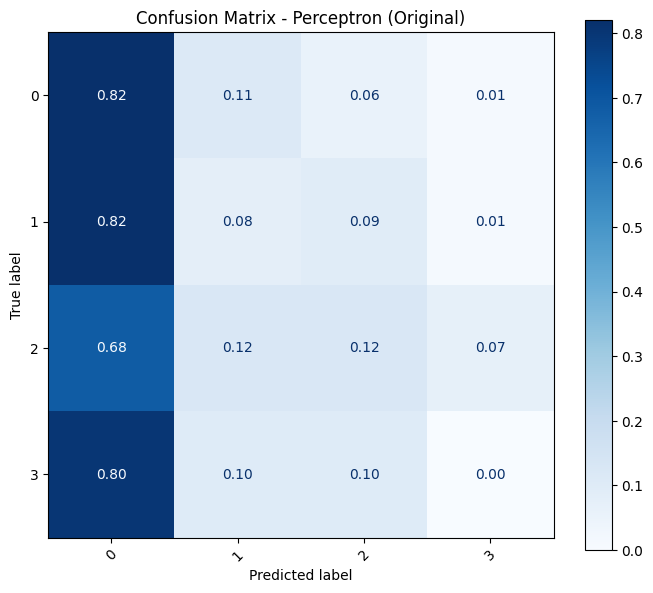

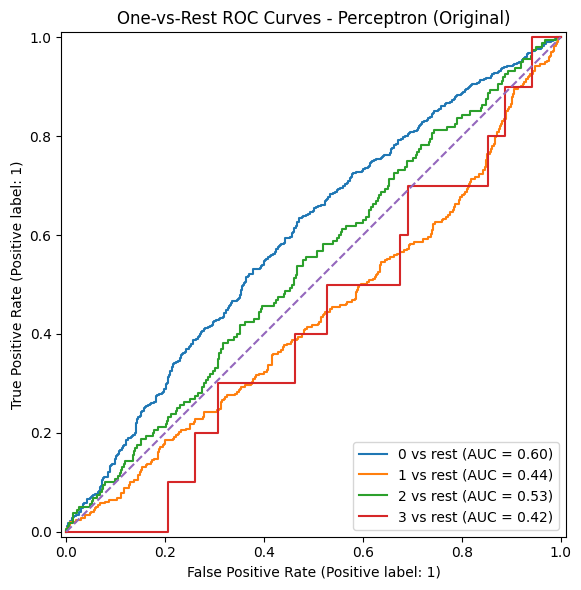

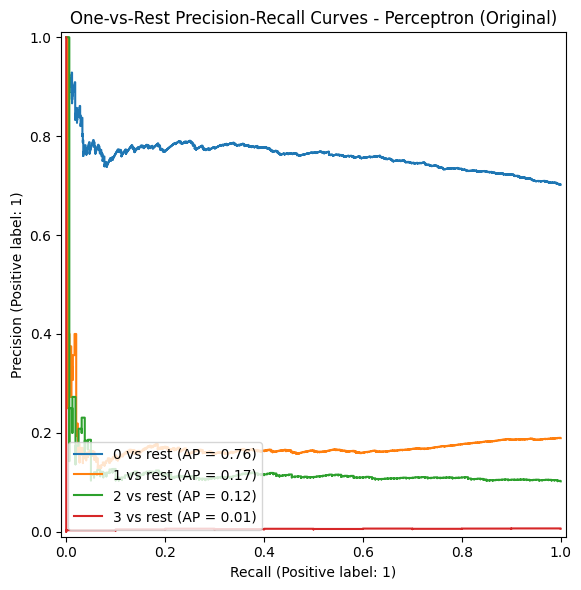


Classification report - Perceptron (Original)


,precision,recall,f1-score,support
0,0.715190,0.821072,0.764482,1101.000000
1,0.137725,0.077441,0.099138,297.000000
2,0.181818,0.125000,0.148148,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.603954,0.603954,0.603954,0.603954
macro avg,0.258683,0.255878,0.252942,1568.000000
weighted avg,0.546823,0.603954,0.570690,1568.000000


Final evaluation on test set for Perceptron + ROS...


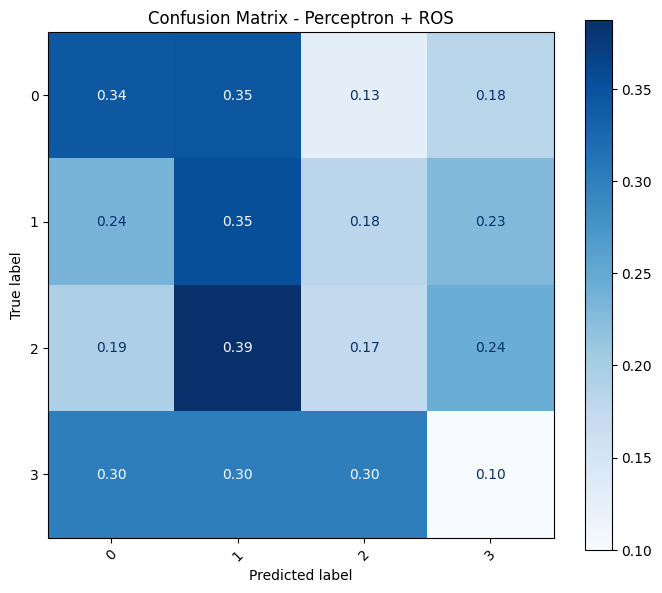

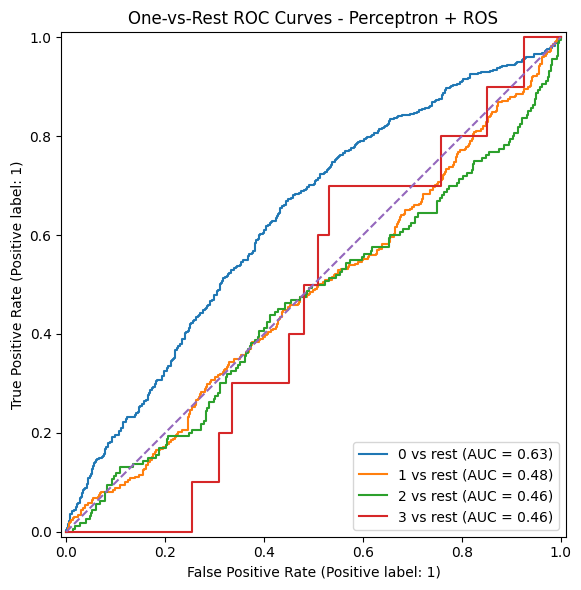

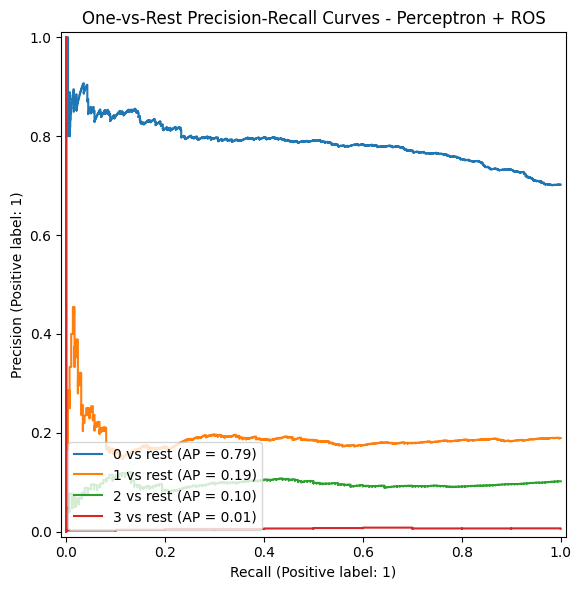


Classification report - Perceptron + ROS


,precision,recall,f1-score,support
0,0.784232,0.343324,0.477574,1101.000000
1,0.190909,0.353535,0.247934,297.000000
2,0.123894,0.175000,0.145078,160.000000
3,0.003226,0.100000,0.006250,10.000000
accuracy,0.326531,0.326531,0.326531,0.326531
macro avg,0.275565,0.242965,0.219209,1568.000000
weighted avg,0.599487,0.326531,0.397143,1568.000000


Final evaluation on test set for Perceptron + ADASYN...


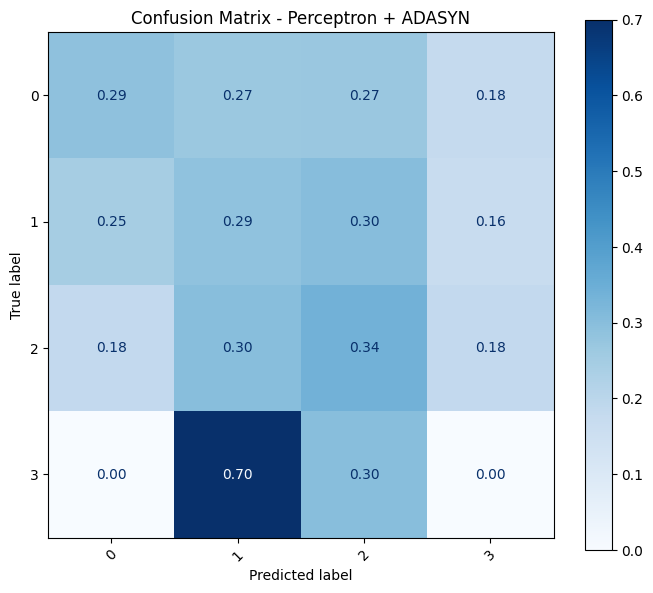

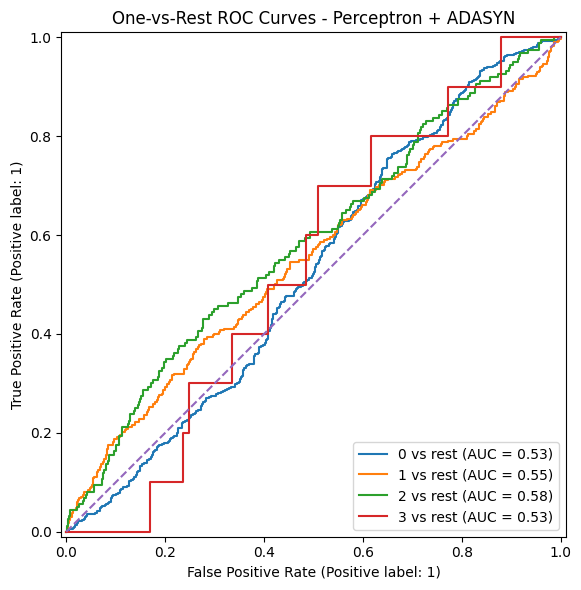

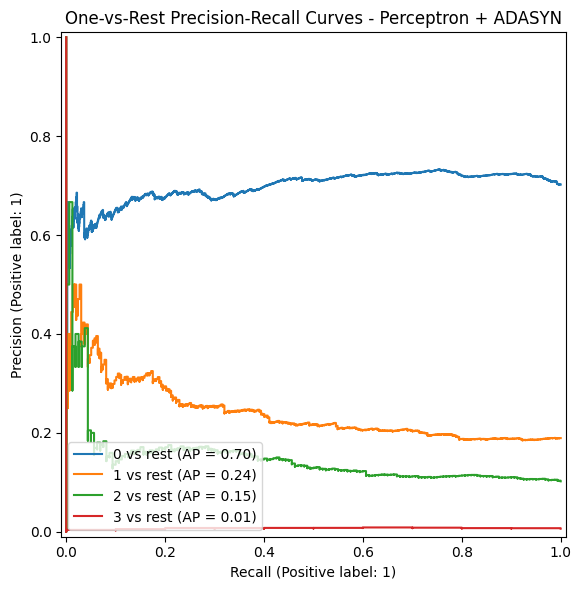


Classification report - Perceptron + ADASYN


,precision,recall,f1-score,support
0,0.756563,0.287920,0.417105,1101.000000
1,0.196305,0.286195,0.232877,297.000000
2,0.121348,0.337500,0.178512,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.290816,0.290816,0.290816,0.290816
macro avg,0.268554,0.227904,0.207124,1568.000000
weighted avg,0.580800,0.290816,0.355204,1568.000000


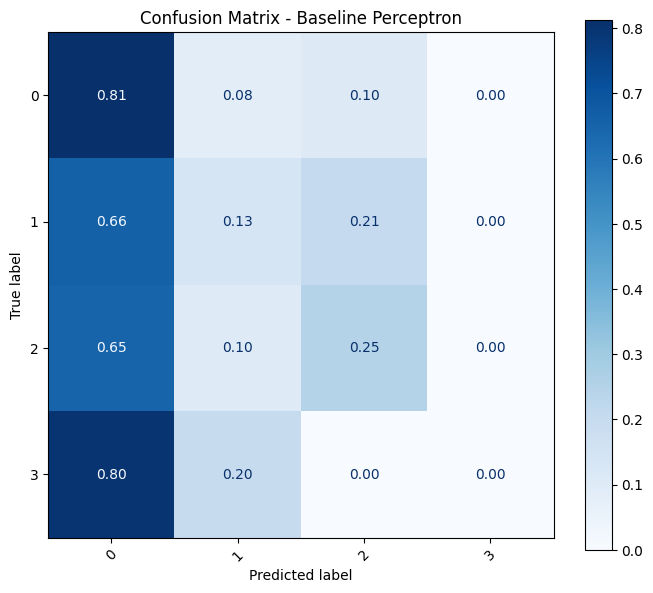

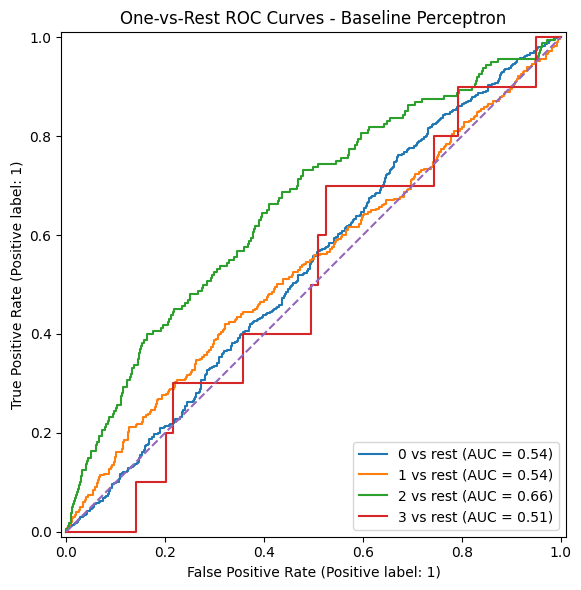

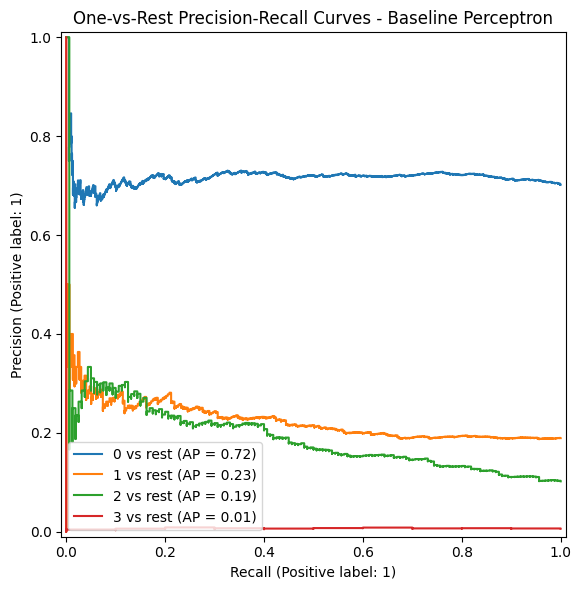


Classification report - Baseline Perceptron


,precision,recall,f1-score,support
0,0.743973,0.812897,0.776910,1101.000000
1,0.266667,0.134680,0.178971,297.000000
2,0.186047,0.250000,0.213333,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.621811,0.621811,0.621811,0.621811
macro avg,0.299172,0.299394,0.292303,1568.000000
weighted avg,0.591889,0.621811,0.601190,1568.000000


In [8]:
for name, pipeline in pipelines.items():
    print(f"Final evaluation on test set for {name}...")
    # Fit the pipeline on the entire training set
    pipeline.fit(X_train, y_train)
    
    # Evaluate on the original test set (X_test, y_test)
    results, report = evaluate_classifier(
        model=pipeline,
        X_test=X_test,      # Il test set originale immacolato
        y_test=y_test,
        model_name=name,
        normalize_cm="true"
    )
perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train)

results_perc, report_perc = evaluate_classifier(
    model=perceptron_model,
    X_test=X_test,      # Il test set originale immacolato
    y_test=y_test,
    model_name="Baseline Perceptron",
    normalize_cm="true"
)

2 classes (imbalanced + balanced)

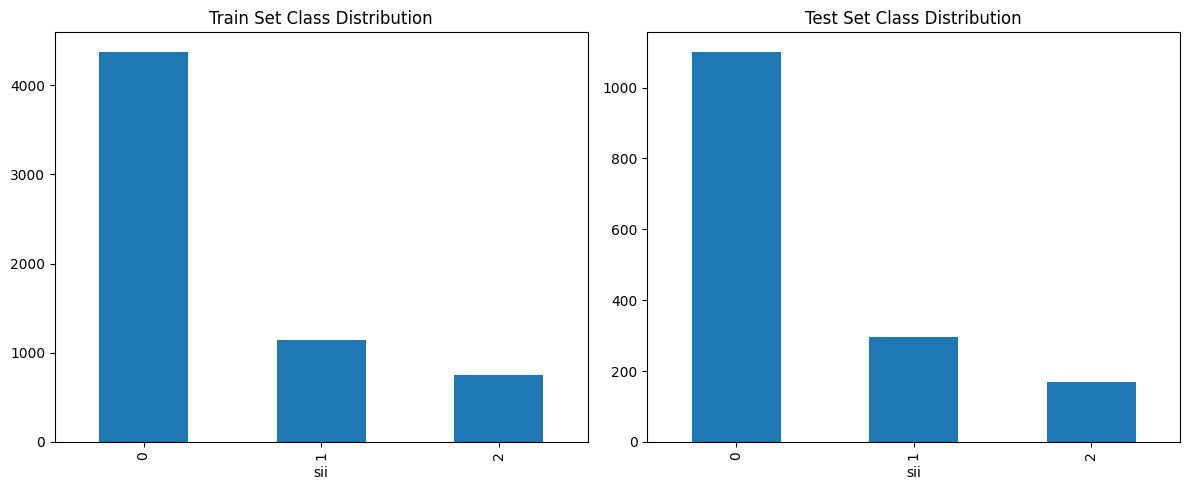

In [12]:
# adding together classes 2 and 3 to create a 3-class classification problem
y_train_3_classes = y_train.apply(lambda x: 0 if x == 0 else (1 if x == 1 else 2))
y_test_3_classes = y_test.apply(lambda x: 0 if x == 0 else (1 if x == 1 else 2))

# plot classes distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
y_train_3_classes.value_counts().plot(kind='bar', title='Train Set Class Distribution')
plt.subplot(1, 2, 2)
y_test_3_classes.value_counts().plot(kind='bar', title='Test Set Class Distribution')
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours 
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import CondensedNearestNeighbour

# Setup: 5-fold Stratified Cross-Validation 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics definition
scoring_metrics = ['balanced_accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

# Three pipelines to compare: Original, ROS, and ADASYN
pipelines = {
    "Perceptron (Original)": Perceptron(penalty="l2", random_state=42, class_weight=None),
    
    "Perceptron + ROS": make_pipeline(
        RandomOverSampler(random_state=42), 
        Perceptron(random_state=42)
    ),
    
    "Perceptron + ADASYN": make_pipeline(
        ADASYN(random_state=42, n_neighbors=5), 
        Perceptron(random_state=42)
    ),

    "Perceptron + Tomek Links": make_pipeline(
        TomekLinks(sampling_strategy='majority'),
        Perceptron(random_state=42)
    ),

    "Perceptron + ENN": make_pipeline(
        EditedNearestNeighbours(sampling_strategy='majority', n_neighbors=5),
        Perceptron(random_state=42)
    ),

    "Perceptron + CNN": make_pipeline(
        CondensedNearestNeighbour(sampling_strategy='majority', n_neighbors=1),
        Perceptron(random_state=42)
    ),

    "Perceptron + ROS + Tomek Links": make_pipeline(
        RandomOverSampler(random_state=42),
        TomekLinks(sampling_strategy='majority'),
        Perceptron(random_state=42)
    ),

    "Perceptron + ROS + ENN": make_pipeline(
        RandomOverSampler(random_state=42),
        EditedNearestNeighbours(sampling_strategy='majority', n_neighbors=5),
        Perceptron(random_state=42)
    ),

    "Perceptron + ADASYN + Tomek Links": make_pipeline(
        ADASYN(random_state=42, n_neighbors=5),
        TomekLinks(sampling_strategy='majority'),
        Perceptron(random_state=42)
    ),

    "Perceptron + ADASYN + ENN": make_pipeline(
        ADASYN(random_state=42, n_neighbors=5),
        EditedNearestNeighbours(sampling_strategy='majority', n_neighbors=5),
        Perceptron(random_state=42)
    )
}

# Dictionary to store the results of cross-validation for each pipeline
cv_results_summary = {}

print("Computing Cross-Validation...\n")

for name, pipeline in pipelines.items():
    print(f"Running {name}...")
    # cross-validation on the original dataset (X_train, y_train)
    # This will give us the performance metrics for each fold, 
    # which we can then summarize
    scores = cross_validate(
        pipeline, X_train, y_train_3_classes, # pipeline defines (1) the model and (2) the resampling strategy 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Compute mean and std for each metric and store in the summary dictionary
    cv_results_summary[name] = {
        "Balanced Accuracy": f"{scores['test_balanced_accuracy'].mean():.4f} (± {scores['test_balanced_accuracy'].std():.3f})",
        "F1 Macro": f"{scores['test_f1_macro'].mean():.4f} (± {scores['test_f1_macro'].std():.3f})",
        "Precision Macro": f"{scores['test_precision_macro'].mean():.4f} (± {scores['test_precision_macro'].std():.3f})",
        "Recall Macro": f"{scores['test_recall_macro'].mean():.4f} (± {scores['test_recall_macro'].std():.3f})"
    }

# Trasformiamo i risultati in un DataFrame pronto da esportare in LaTeX o inserire nella tesi
df_results = pd.DataFrame(cv_results_summary).T
display(df_results)

Computing Cross-Validation...

Running Perceptron (Original)...
Running Perceptron + ROS...
Running Perceptron + ADASYN...
Running Perceptron + Tomek Links...
Running Perceptron + ENN...
Running Perceptron + CNN...
Running Perceptron + ROS + Tomek Links...
Running Perceptron + ROS + ENN...
Running Perceptron + ADASYN + Tomek Links...
Running Perceptron + ADASYN + ENN...


,Balanced Accuracy,F1 Macro,Precision Macro,Recall Macro
Perceptron (Original),0.3938 (± 0.028),0.3931 (± 0.028),0.4027 (± 0.027),0.3938 (± 0.028)
Perceptron + ROS,0.3811 (± 0.023),0.3280 (± 0.019),0.3695 (± 0.013),0.3811 (± 0.023)
Perceptron + ADASYN,0.3961 (± 0.035),0.3422 (± 0.029),0.3777 (± 0.021),0.3961 (± 0.035)
Perceptron + Tomek Links,0.4098 (± 0.036),0.4029 (± 0.035),0.4193 (± 0.031),0.4098 (± 0.036)
Perceptron + ENN,0.4280 (± 0.027),0.3959 (± 0.018),0.4021 (± 0.014),0.4280 (± 0.027)
Perceptron + CNN,0.3488 (± 0.044),0.2990 (± 0.023),0.3378 (± 0.030),0.3488 (± 0.044)
Perceptron + ROS + Tomek Links,0.4140 (± 0.031),0.3410 (± 0.027),0.3872 (± 0.013),0.4140 (± 0.031)
Perceptron + ROS + ENN,0.3727 (± 0.019),0.2545 (± 0.023),0.3507 (± 0.013),0.3727 (± 0.019)
Perceptron + ADASYN + Tomek Links,0.3946 (± 0.064),0.3283 (± 0.062),0.3769 (± 0.041),0.3946 (± 0.064)
Perceptron + ADASYN + ENN,0.3838 (± 0.042),0.3355 (± 0.042),0.3705 (± 0.029),0.3838 (± 0.042)


Final evaluation on test set for Perceptron (Original)...


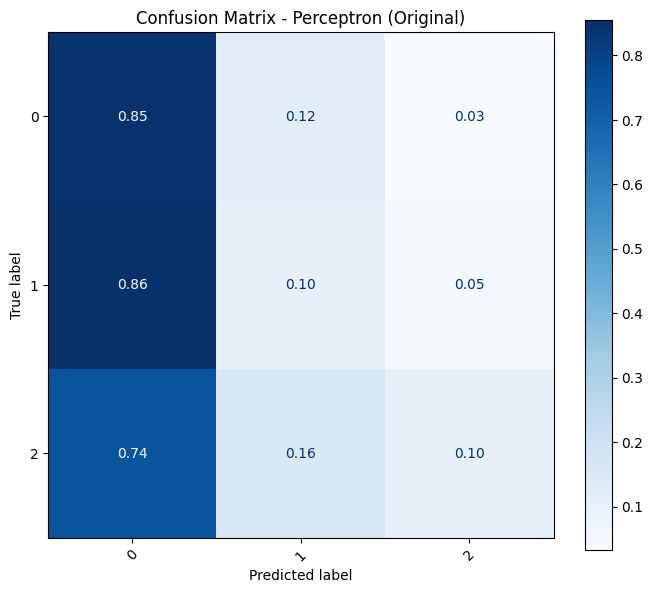

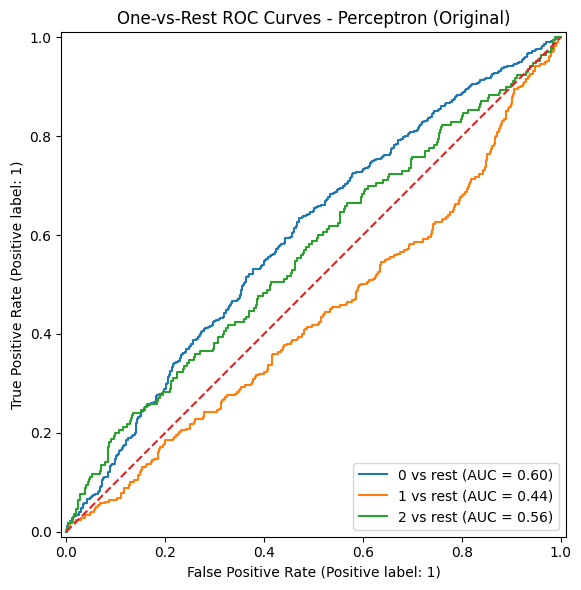

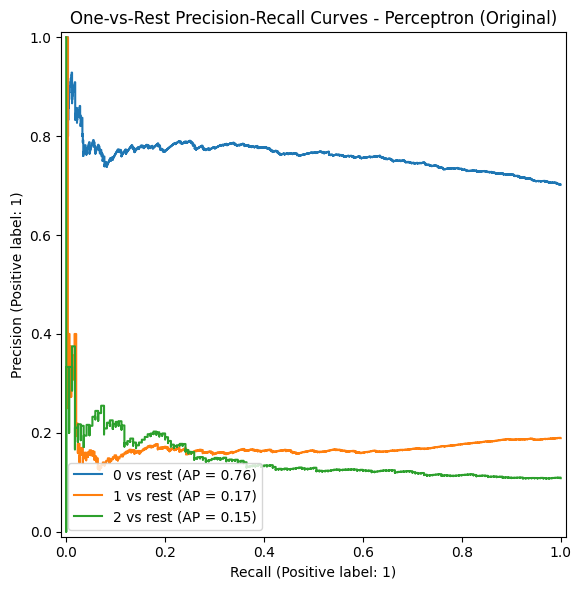


Classification report - Perceptron (Original)


,precision,recall,f1-score,support
0,0.710807,0.848320,0.773499,1101.000
1,0.155080,0.097643,0.119835,297.000
2,0.253731,0.100000,0.143460,170.000
accuracy,0.625000,0.625000,0.625000,0.625
macro avg,0.373206,0.348654,0.345598,1568.000
weighted avg,0.555989,0.625000,0.581378,1568.000


Final evaluation on test set for Perceptron + ROS...


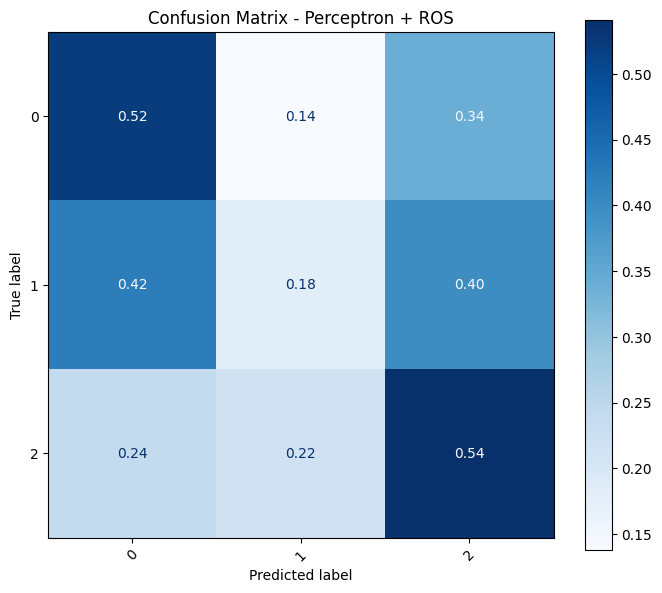

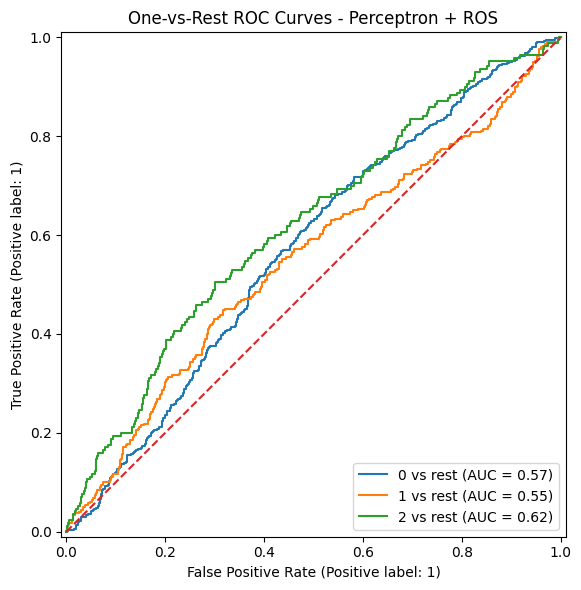

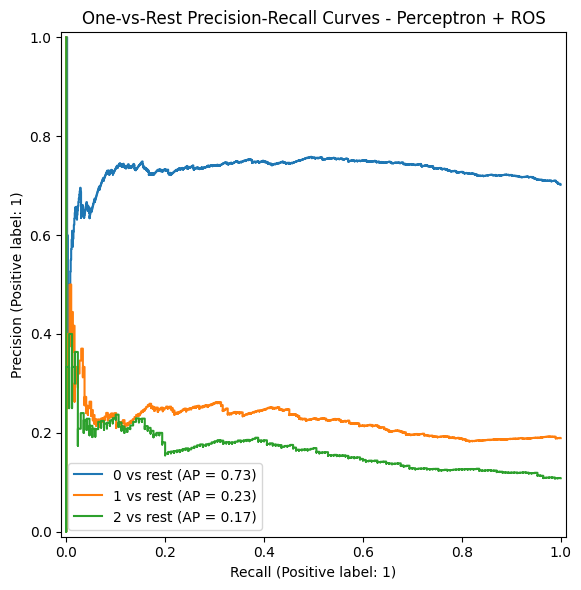


Classification report - Perceptron + ROS


,precision,recall,f1-score,support
0,0.775978,0.522252,0.624321,1101.000000
1,0.222222,0.181818,0.200000,297.000000
2,0.157534,0.541176,0.244032,170.000000
accuracy,0.459821,0.459821,0.459821,0.459821
macro avg,0.385245,0.415082,0.356118,1568.000000
weighted avg,0.604039,0.459821,0.502719,1568.000000


Final evaluation on test set for Perceptron + ADASYN...


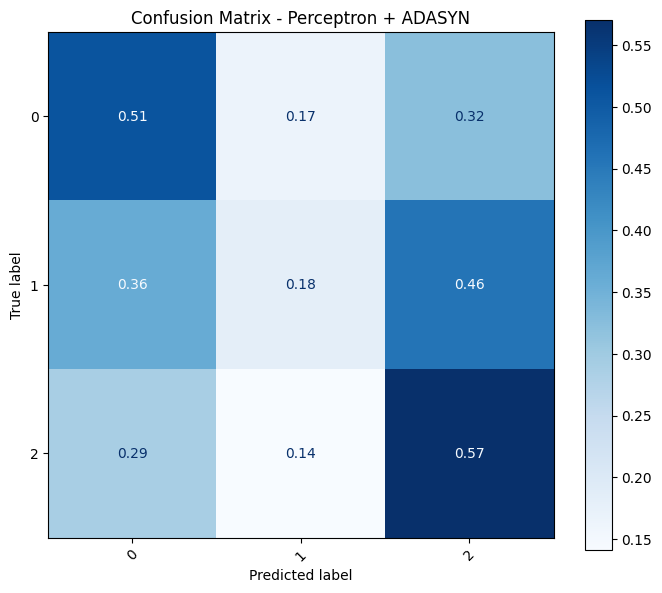

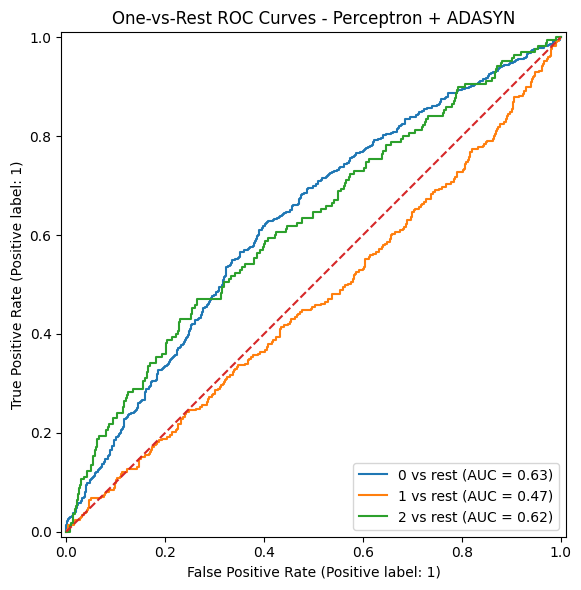

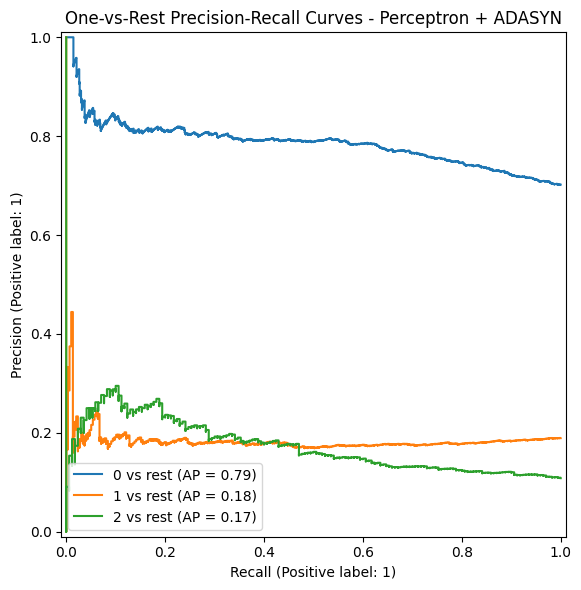


Classification report - Perceptron + ADASYN


,precision,recall,f1-score,support
0,0.783032,0.511353,0.618681,1101.000000
1,0.207692,0.181818,0.193896,297.000000
2,0.164686,0.570588,0.255599,170.000000
accuracy,0.455357,0.455357,0.455357,0.455357
macro avg,0.385137,0.421253,0.356059,1568.000000
weighted avg,0.607015,0.455357,0.498857,1568.000000


Final evaluation on test set for Perceptron + Tomek Links...


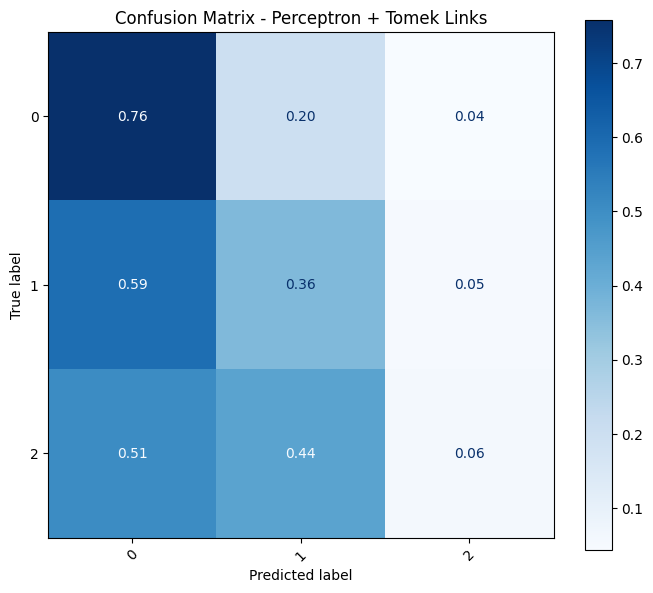

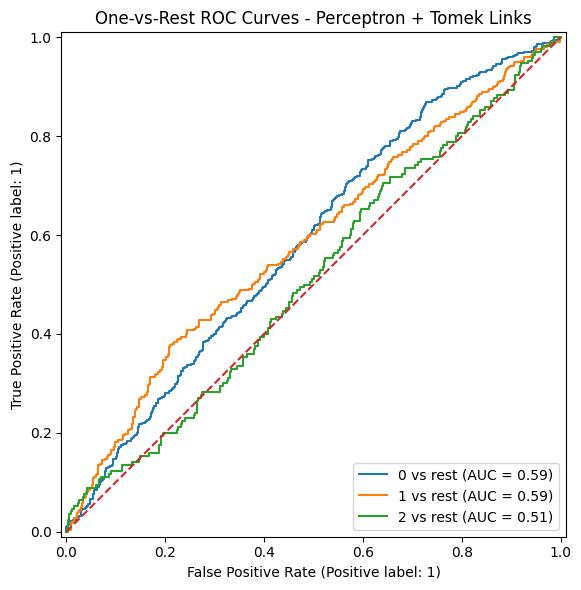

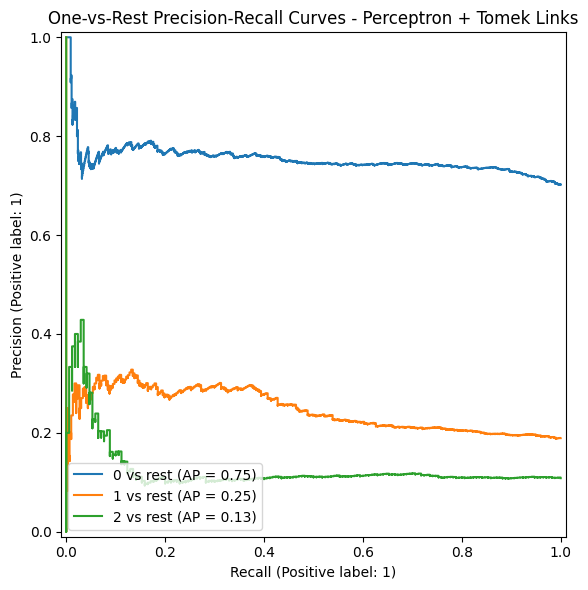


Classification report - Perceptron + Tomek Links


,precision,recall,f1-score,support
0,0.762557,0.758401,0.760474,1101.000000
1,0.270000,0.363636,0.309900,297.000000
2,0.136986,0.058824,0.082305,170.000000
accuracy,0.607781,0.607781,0.607781,0.607781
macro avg,0.389848,0.393620,0.384226,1568.000000
weighted avg,0.601437,0.607781,0.601603,1568.000000


Final evaluation on test set for Perceptron + ENN...


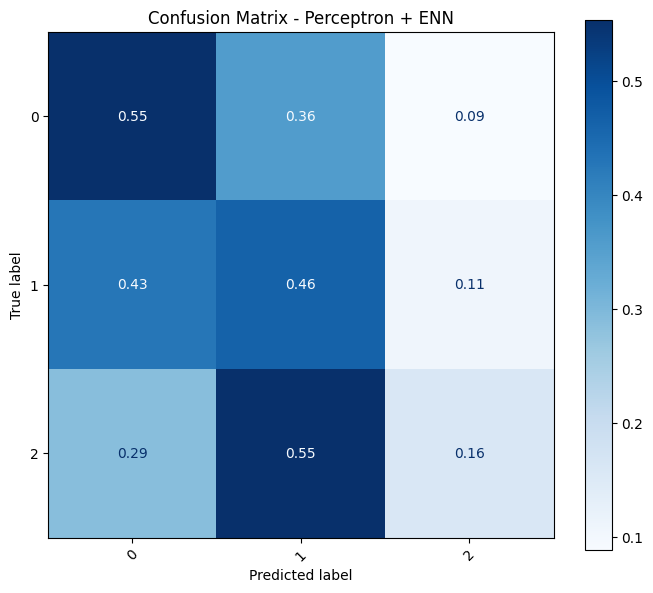

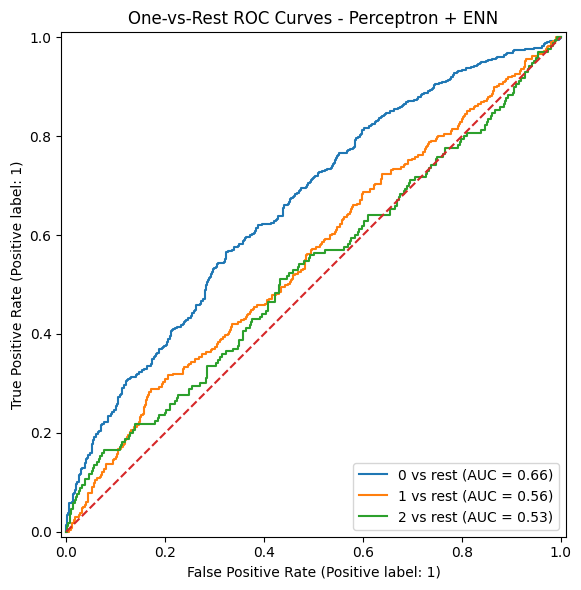

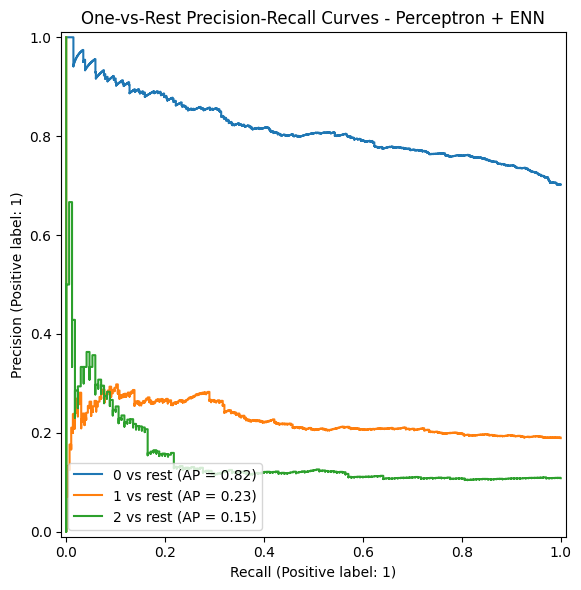


Classification report - Perceptron + ENN


,precision,recall,f1-score,support
0,0.776081,0.554042,0.646529,1101.00000
1,0.220800,0.464646,0.299349,297.00000
2,0.171975,0.158824,0.165138,170.00000
accuracy,0.494260,0.494260,0.494260,0.49426
macro avg,0.389619,0.392504,0.370339,1568.00000
weighted avg,0.605407,0.494260,0.528577,1568.00000


Final evaluation on test set for Perceptron + CNN...


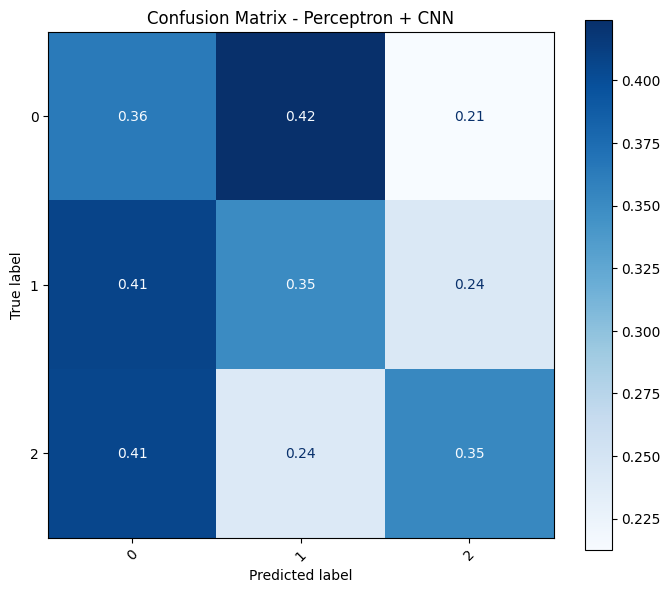

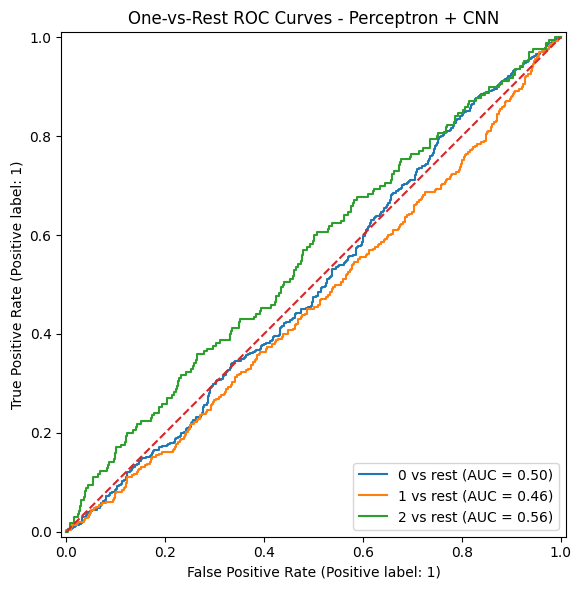

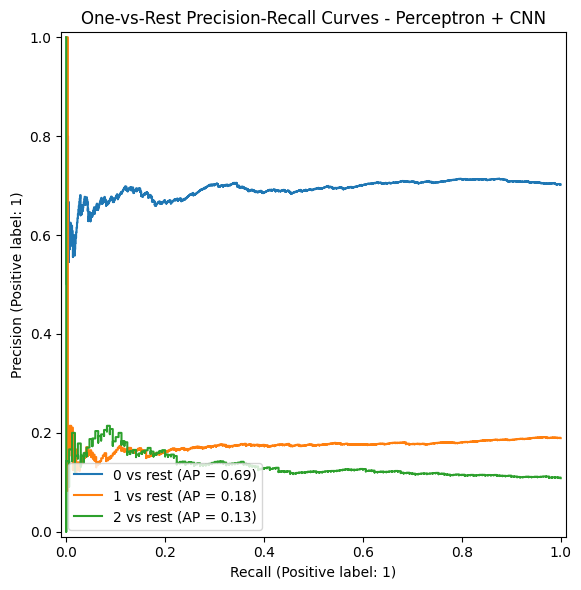


Classification report - Perceptron + CNN


,precision,recall,f1-score,support
0,0.677966,0.363306,0.473093,1101.000000
1,0.169935,0.350168,0.228823,297.000000
2,0.163934,0.352941,0.223881,170.000000
accuracy,0.359694,0.359694,0.359694,0.359694
macro avg,0.337278,0.355472,0.308599,1568.000000
weighted avg,0.526008,0.359694,0.399806,1568.000000


Final evaluation on test set for Perceptron + ROS + Tomek Links...


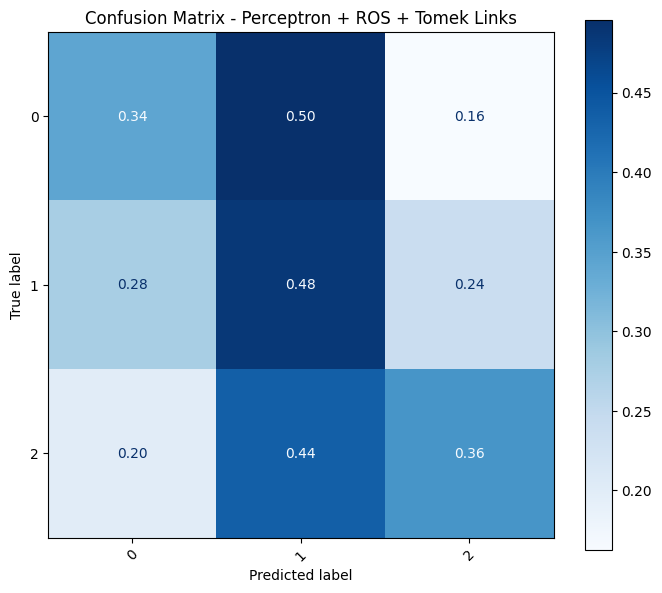

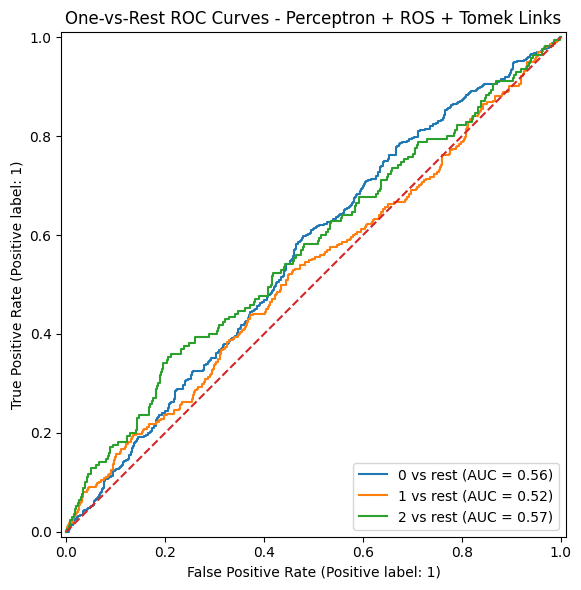

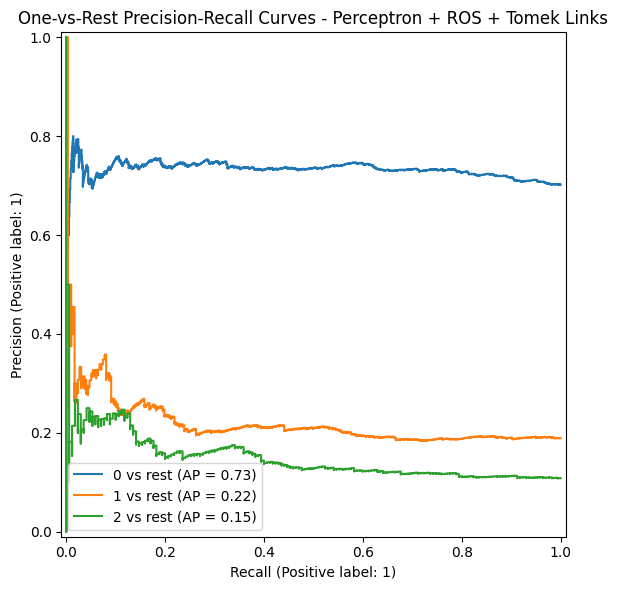


Classification report - Perceptron + ROS + Tomek Links


,precision,recall,f1-score,support
0,0.764228,0.341508,0.472065,1101.000000
1,0.188482,0.484848,0.271442,297.000000
2,0.198718,0.364706,0.257261,170.000000
accuracy,0.371173,0.371173,0.371173,0.371173
macro avg,0.383809,0.397021,0.333590,1568.000000
weighted avg,0.593862,0.371173,0.410776,1568.000000


Final evaluation on test set for Perceptron + ROS + ENN...


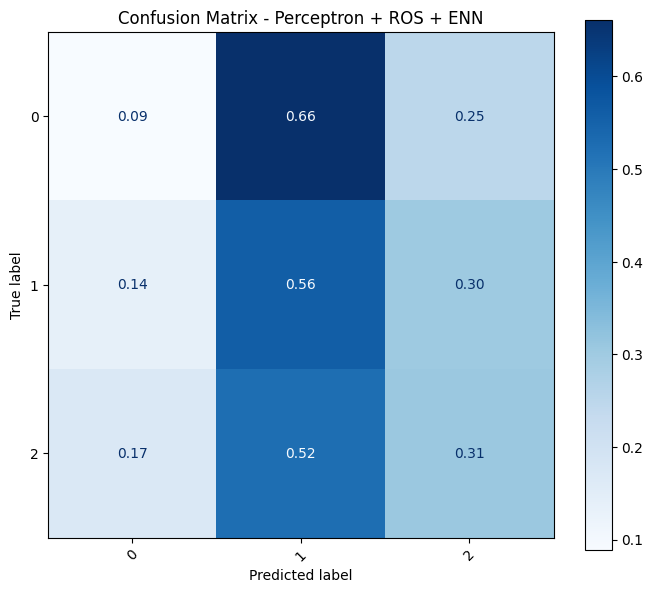

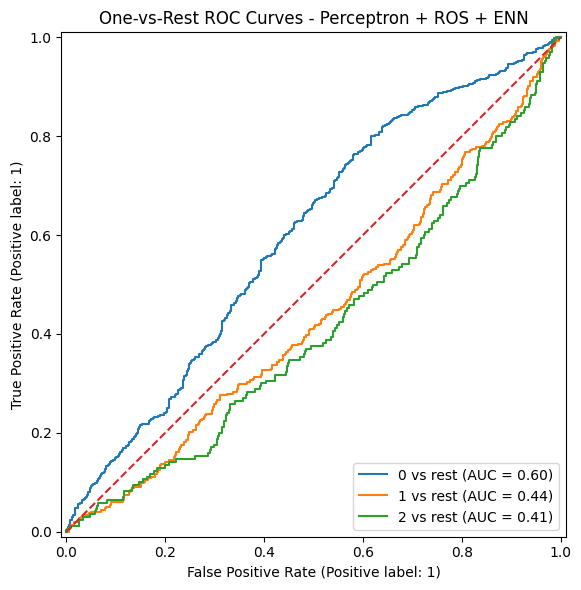

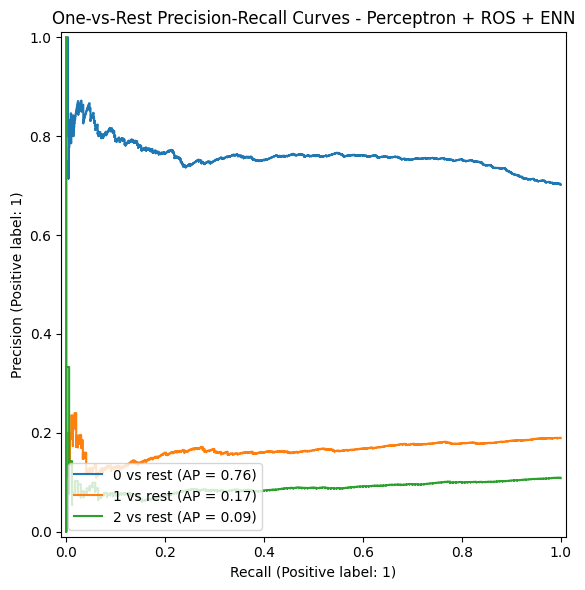


Classification report - Perceptron + ROS + ENN


,precision,recall,f1-score,support
0,0.583333,0.089010,0.154452,1101.000000
1,0.168871,0.558923,0.259375,297.000000
2,0.124700,0.305882,0.177172,170.000000
accuracy,0.201531,0.201531,0.201531,0.201531
macro avg,0.292301,0.317938,0.197000,1568.000000
weighted avg,0.455104,0.201531,0.176789,1568.000000


Final evaluation on test set for Perceptron + ADASYN + Tomek Links...


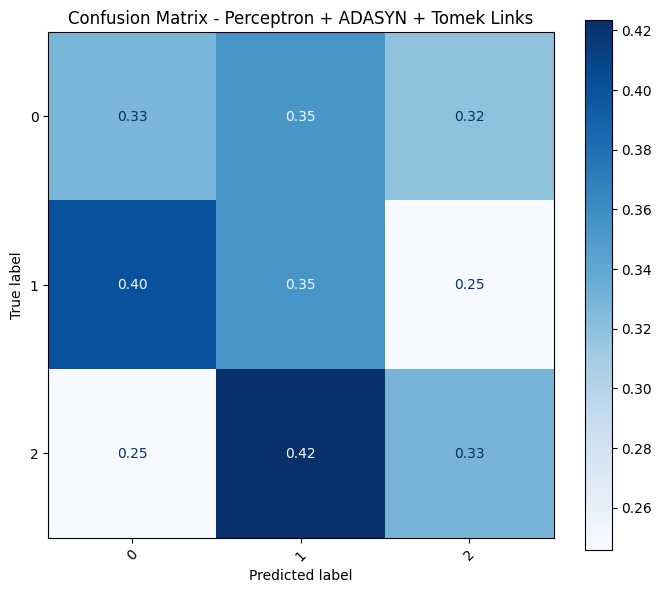

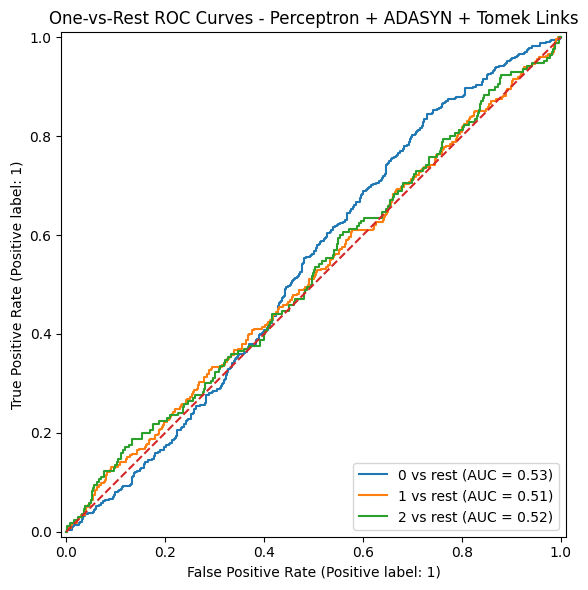

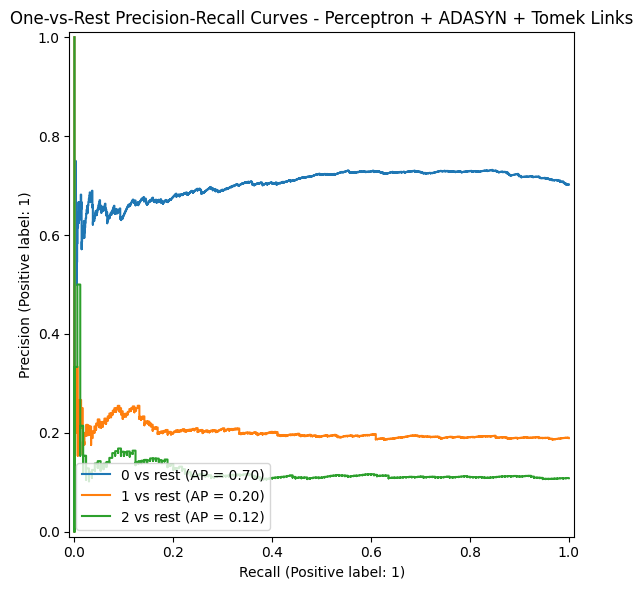


Classification report - Perceptron + ADASYN + Tomek Links


,precision,recall,f1-score,support
0,0.691571,0.327884,0.444855,1101.000000
1,0.185512,0.353535,0.243337,297.000000
2,0.116667,0.329412,0.172308,170.000000
accuracy,0.332908,0.332908,0.332908,0.332908
macro avg,0.331250,0.336944,0.286833,1568.000000
weighted avg,0.533387,0.332908,0.377136,1568.000000


Final evaluation on test set for Perceptron + ADASYN + ENN...


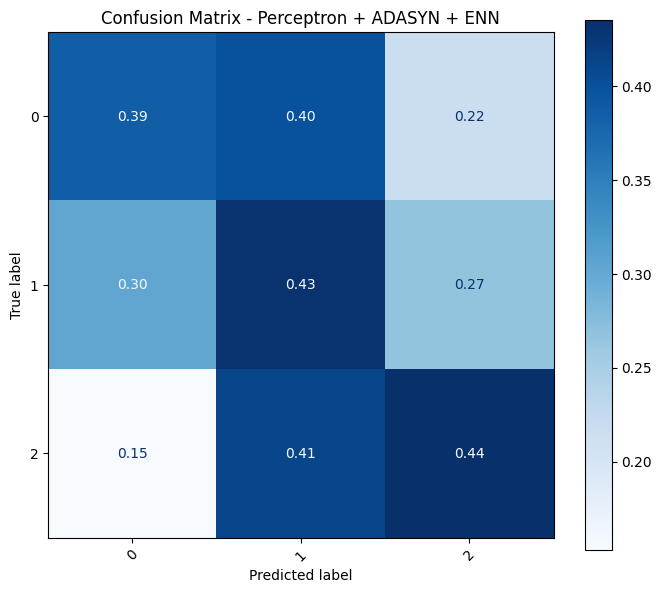

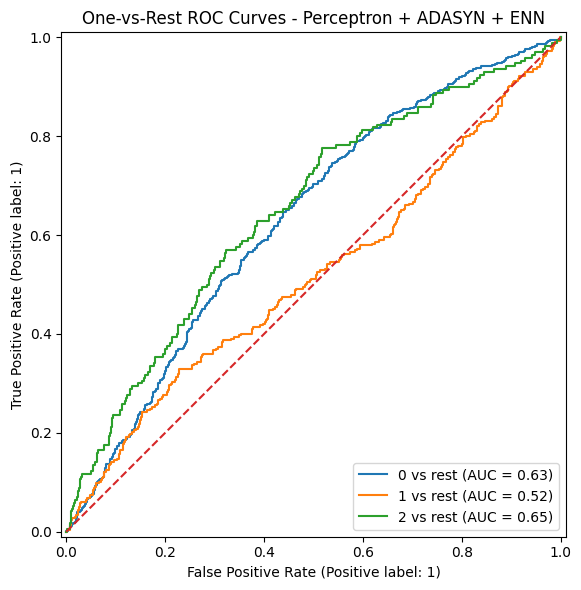

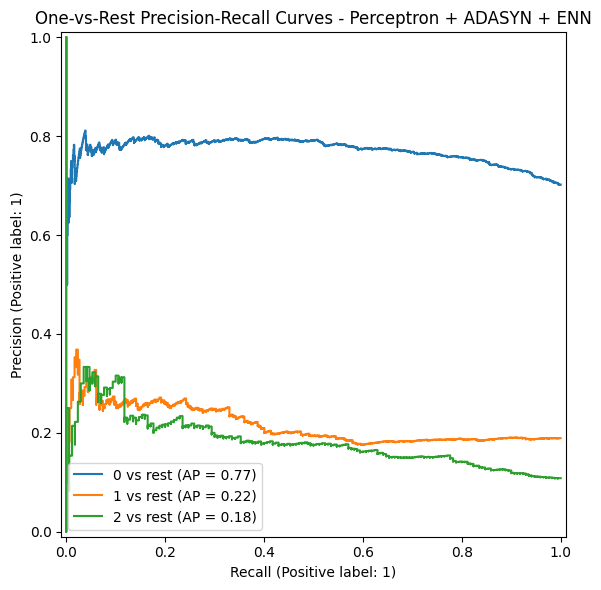


Classification report - Perceptron + ADASYN + ENN


,precision,recall,f1-score,support
0,0.785185,0.385104,0.516758,1101.000000
1,0.200627,0.430976,0.273797,297.000000
2,0.189744,0.435294,0.264286,170.000000
accuracy,0.399235,0.399235,0.399235,0.399235
macro avg,0.391852,0.417125,0.351614,1568.000000
weighted avg,0.609905,0.399235,0.443365,1568.000000


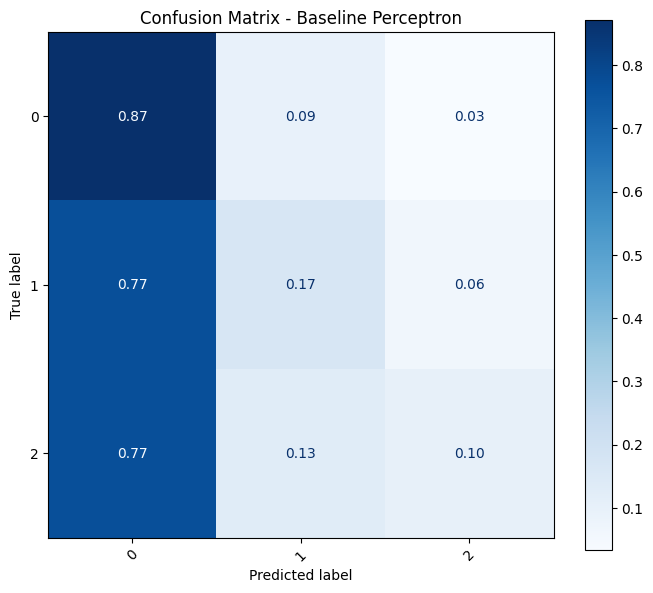

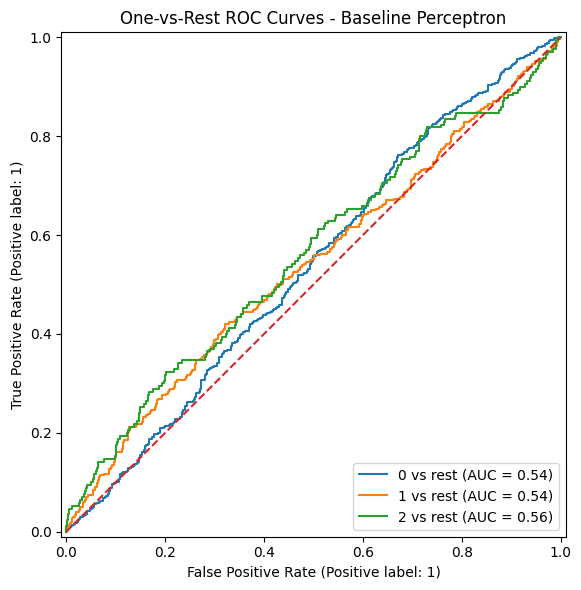

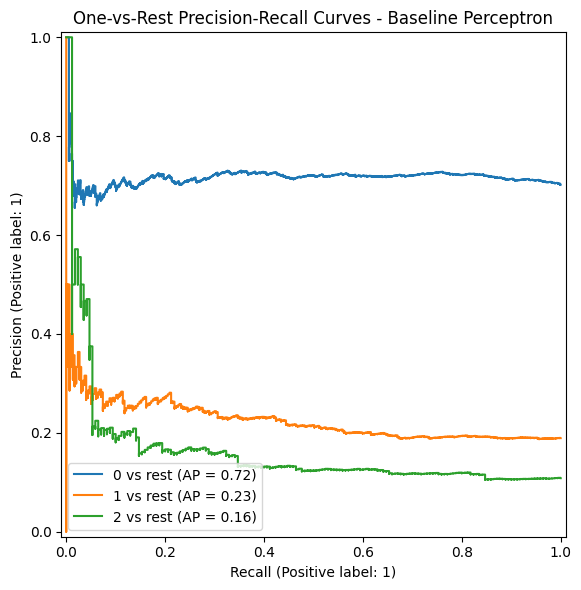


Classification report - Baseline Perceptron


,precision,recall,f1-score,support
0,0.727273,0.871935,0.793061,1101.000000
1,0.284091,0.168350,0.211416,297.000000
2,0.236111,0.100000,0.140496,170.000000
accuracy,0.654974,0.654974,0.654974,0.654974
macro avg,0.415825,0.380095,0.381658,1568.000000
weighted avg,0.590077,0.654974,0.612140,1568.000000


In [14]:
for name, pipeline in pipelines.items():
    print(f"Final evaluation on test set for {name}...")
    # Fit the pipeline on the entire training set
    pipeline.fit(X_train, y_train_3_classes)
    
    # Evaluate on the original test set (X_test, y_test)
    results, report = evaluate_classifier(
        model=pipeline,
        X_test=X_test,      # Il test set originale immacolato
        y_test=y_test_3_classes,
        model_name=name,
        normalize_cm="true"
    )
perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train_3_classes)

results_perc, report_perc = evaluate_classifier(
    model=perceptron_model,
    X_test=X_test,      # Il test set originale immacolato
    y_test=y_test_3_classes,
    model_name="Baseline Perceptron",
    normalize_cm="true"
)

# B) **Multi-Layer Perceptron**

## 1. Imbalanced classes

Hyperparameter tuning using 3-fold cross-validation to choose the best model configuration

In [ ]:

# ==========================================
# HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
print("Hyperparameter Tuning beginning...")

# Definiamo la griglia dei parametri da testare
param_grid = {
    'hidden_layer_sizes': [(128, 64, 32,), (128, 32,), (64, 32,), (10, 10, 10), (100, 100, 100)], # hidden layers dimensions and number of layers
    'alpha': [0.0001, 0.001, 0.01], # L2 regularization term to prevent overfitting
    'learning_rate_init': [0.001, 0.01], # Initial learning rate (if using 'constant' learning rate schedule)
    'learning_rate': ['constant', 'adaptive'], # Learning rate schedule (if using 'sgd' solver)
    'activation': ['relu', 'tanh', 'logistic', 'identity'], # Hidden layer activation function
    'early_stopping': [True, False], # Whether to use early stopping to terminate training when validation score is not improving
    'momentum': [0.9, 0.95, 0.99], # Momentum for gradient descent update (if using 'sgd' solver)
    'solver': ['adam', 'sgd', 'lbfgs'], # Optimizer for weight updates
    'max_iter': [10, 50, 100, 200], # Maximum number of iterations (epochs) to train the model
}

param_distributions = [
    # adam configuration
    {
        'hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'activation': ['relu', 'tanh', 'logistic'], # Activation functions
        'solver': ['adam'], 
        'alpha': [0.0001, 0.001, 0.01], # L2 regularization term
        'learning_rate_init': [0.001, 0.01], # Initial learning rate (not used by 'adam', but we can still include it for consistency)
        'early_stopping': [True, False], # Eary stopping
        'max_iter': [150, 200, 300] # epochs
    },
    # SGD solver (Stochastic Gradient Descent)
    {
        'hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['sgd'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'], # learning rate schedule for SGD
        'momentum': [0.9, 0.95, 0.99], # momentum is useful for SGD to accelerate convergence and escape local minima
        'early_stopping': [True, False],
        'max_iter': [150, 200, 300]
    }
]

mlp_base = MLPClassifier(max_iter=150, random_state=42, early_stopping=False)

# Looks for the configuration that maximizes the balanced accuracy score using 3-fold cross-validation
random_search = RandomizedSearchCV(
    mlp_base, param_distributions=`param_distributions` is a list containing dictionaries where each dictionary represents a specific configuration of hyperparameters to be tested during the randomized search process. Each dictionary in `param_distributions` defines a set of hyperparameters that will be sampled from during the search.
    `param_distributions` is a list containing dictionaries where each dictionary represents a specific configuration of hyperparameters to be tested during the randomized search process. Each dictionary in `param_distributions` specifies a set of hyperparameters and their possible values for a particular configuration of the MLPClassifier model.
    param_distributions, cv=3, scoring='balanced_accuracy', n_jobs=-1, n_iter=50
)

# Fit the grid search to the training data
random_search.fit(X_train, y_train)

# Print the best parameters found by the grid search
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


Hyperparameter Tuning beginning...
Best Parameters: {'solver': 'sgd', 'momentum': 0.95, 'max_iter': 150, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': (128, 64, 32), 'early_stopping': False, 'alpha': 0.001, 'activation': 'relu'}

Best Balanced Accuracy Score from Randomized Search: 0.3123



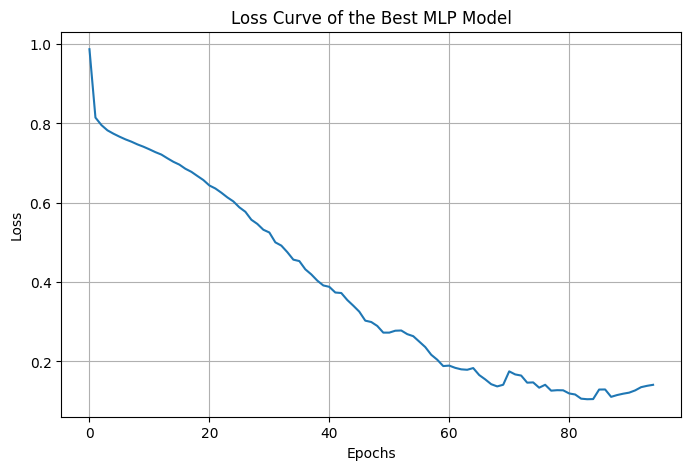

In [34]:
# loss curve of the best model
best_mlp = random_search.best_estimator_
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.title('Loss Curve of the Best MLP Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()

Generalization Error Plot of the best model 

Generating Generalization Curve...


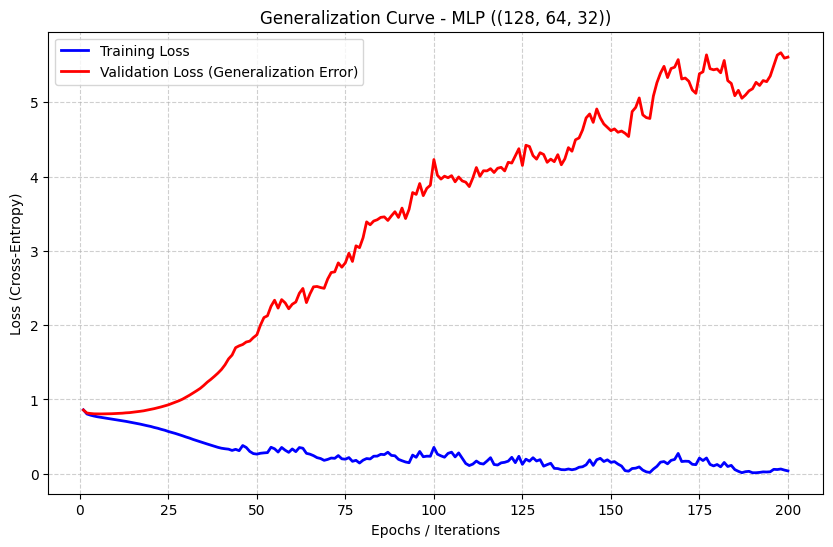

The network does not use early stopping.



In [31]:
# ==========================================
# Generalization Error Plot (Overfitting Check)
# ==========================================

# Split the training data into training and validation sets to check for overfitting
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Generating Generalization Curve...")

# Choose the best model from the grid search to plot the generalization curve

# set early_stopping to False to train for a fixed number of epochs and record the losses at each epoch
best_params['early_stopping'] = False

mlp_curve = MLPClassifier(**best_params, random_state=42)

classes = np.unique(y_train)
epochs = 200
train_losses = []
val_losses = []

# Train the model for a number of epochs and record the training and validation losses at each epoch
for epoch in range(epochs):
    # Perform one epoch of training
    mlp_curve.partial_fit(X_tr, y_tr, classes=classes)
    # Predict probabilities for training and validation sets
    train_proba = mlp_curve.predict_proba(X_tr)
    val_proba = mlp_curve.predict_proba(X_val)
    # Calculate log loss for training and validation sets
    train_losses.append(log_loss(y_tr, train_proba, labels=classes))
    val_losses.append(log_loss(y_val, val_proba, labels=classes))

# Generalization Error plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (Generalization Error)', color='red', lw=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Loss (Cross-Entropy)')
plt.title(f'Generalization Curve - MLP ({best_params["hidden_layer_sizes"]})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# set early_stopping to the original value (True or False) based on the best parameters found during the search
best_params['early_stopping'] = random_search.best_params_['early_stopping']

# print if the network uses early stopping or not
if best_params['early_stopping']:
    print("The network uses early stopping to prevent overfitting.\n")
    # print the iteration at which early stopping would have occurred based on the validation loss
    early_stopping_epoch = np.argmin(val_losses) + 1
    print(f"Early stopping would have occurred at epoch: {early_stopping_epoch}\n")
else:
    print("The network does not use early stopping.\n")



Final Evaluation of the Best Model on the test set

Final Evaluation on Test Set...


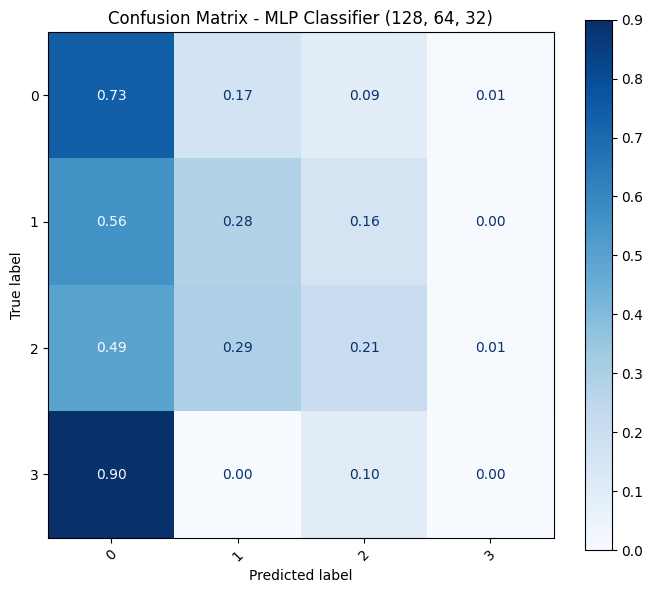

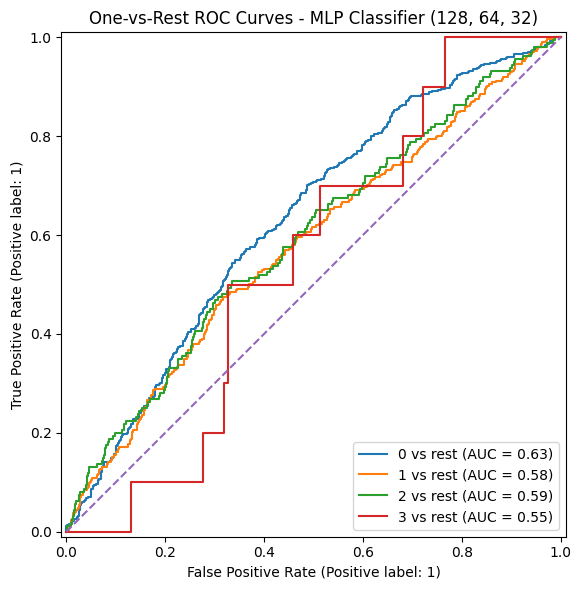

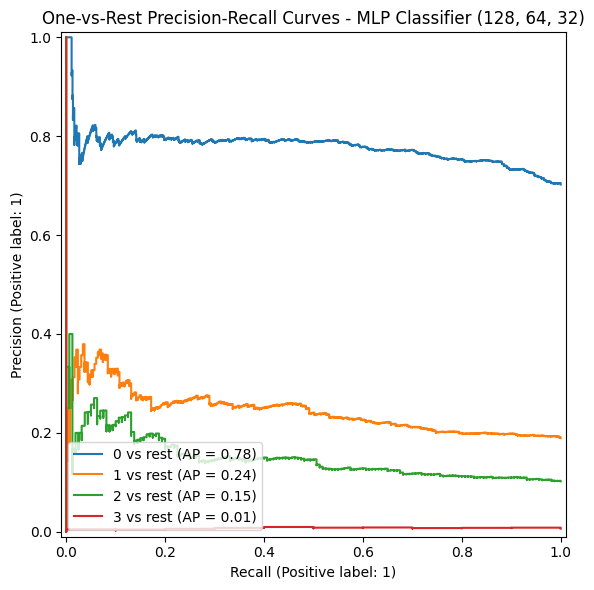


Classification report - MLP Classifier (128, 64, 32)


,precision,recall,f1-score,support
0,0.761770,0.734787,0.748035,1101.000000
1,0.268371,0.282828,0.275410,297.000000
2,0.178378,0.206250,0.191304,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.590561,0.590561,0.590561,0.590561
macro avg,0.302130,0.305966,0.303687,1568.000000
weighted avg,0.603926,0.590561,0.596934,1568.000000


In [32]:
# ==========================================
# 3. Final Evaluation on Test Set
# ==========================================
print("Final Evaluation on Test Set...")

# Train the final model on the entire training set (train + validation) using the best hyperparameters found
final_mlp = MLPClassifier(**best_params, random_state=42)
final_mlp.fit(X_train, y_train)

# Evaluation on the test set using the evaluation function
results, report_df = evaluate_classifier(
    model=final_mlp,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP Classifier {best_params['hidden_layer_sizes']}",
    normalize_cm="true"
)

# 2. Handling Imbalanced classes
- Random oversampling
- Adasyn

In [37]:
from collections import Counter
from imblearn.over_sampling import ADASYN, RandomOverSampler

# Starting distribution check
print("=== DISTRIBUZIONE ORIGINALE ===")
print(f"Classi nel Train Set originale: {Counter(y_train)}")
print("-" * 40)

# ==========================================
# 1. METHOD 1: RANDOM OVERSAMPLING (ROS)
# ==========================================

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("=== DOPO RANDOM OVERSAMPLING ===")
print(f"Dimensioni X_train_ros: {X_train_ros.shape}")
print(f"Distribuzione classi: {Counter(y_train_ros)}")
print("-" * 40)

# ==========================================
# 2. METHOD 2: ADASYN
# ==========================================

adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("=== DOPO ADASYN ===")
print(f"Dimensioni X_train_adasyn: {X_train_adasyn.shape}")
print(f"Distribuzione classi: {Counter(y_train_adasyn)}")
print("-" * 40)

=== DISTRIBUZIONE ORIGINALE ===
Classi nel Train Set originale: Counter({0: 4375, 1: 1147, 2: 686, 3: 63})
----------------------------------------
=== DOPO RANDOM OVERSAMPLING ===
Dimensioni X_train_ros: (17500, 32)
Distribuzione classi: Counter({0: 4375, 1: 4375, 2: 4375, 3: 4375})
----------------------------------------
=== DOPO ADASYN ===
Dimensioni X_train_adasyn: (17238, 32)
Distribuzione classi: Counter({0: 4375, 3: 4347, 2: 4306, 1: 4210})
----------------------------------------


## 2.1 Random Oversampling 

The random search is executed over the training set where the minority classes are oversampled 

In [39]:
from imblearn.pipeline import Pipeline as ImbPipeline
# ==========================================
# HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
print("Hyperparameter Tuning beginning...")

# Definiamo la griglia dei parametri da testare
param_grid = {
    'hidden_layer_sizes': [(128, 64, 32,), (128, 32,), (64, 32,), (10, 10, 10), (100, 100, 100)], # hidden layers dimensions and number of layers
    'alpha': [0.0001, 0.001, 0.01], # L2 regularization term to prevent overfitting
    'learning_rate_init': [0.001, 0.01], # Initial learning rate (if using 'constant' learning rate schedule)
    'learning_rate': ['constant', 'adaptive'], # Learning rate schedule (if using 'sgd' solver)
    'activation': ['relu', 'tanh', 'logistic', 'identity'], # Hidden layer activation function
    'early_stopping': [True, False], # Whether to use early stopping to terminate training when validation score is not improving
    'momentum': [0.9, 0.95, 0.99], # Momentum for gradient descent update (if using 'sgd' solver)
    'solver': ['adam', 'sgd', 'lbfgs'], # Optimizer for weight updates
    'max_iter': [10, 50, 100, 200], # Maximum number of iterations (epochs) to train the model
}

param_distributions = [
    # adam configuration
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'], 
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001, 0.01], 
        'mlp__learning_rate_init': [0.001, 0.01], # Usato da Adam come step size iniziale
        'mlp__early_stopping': [True, False], 
        'mlp__max_iter': [150, 200, 300] 
    },
    # SGD solver (Stochastic Gradient Descent)
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['sgd'],
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__learning_rate': ['constant', 'adaptive'], 
        'mlp__momentum': [0.9, 0.95, 0.99], 
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    }
]

# pipeline with random oversampling and MLP classifier for hyperparameter tuning
mlp_base = MLPClassifier(random_state=42)
ros = RandomOverSampler(random_state=42)

pipeline_cv = ImbPipeline([
    ('ros', ros), # first, we apply random oversampling to balance the classes in the training data
    ('mlp', mlp_base)# then, we apply the MLP classifier to the resampled data
])

random_search = RandomizedSearchCV(
    pipeline_cv, 
    param_distributions=param_distributions, 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    n_iter=50,
    random_state=42
)


# Fit the grid search to the training data
random_search.fit(X_train, y_train)
# Note: we fit the random search on the original training data (X_train, y_train) 
# because the pipeline itself includes the random oversampling step, 
# so during each fold of the cross-validation, the training data 
# will be resampled accordingly. This allows us to properly evaluate 
# the performance of the model with the resampling strategy included in the pipeline,
# ensuring that the hyperparameter tuning process accounts for the effects of random 
# oversampling on the training data.


# Print the best parameters found by the grid search
best_params = {k.replace('mlp__', ''): v for k, v in random_search.best_params_.items()}
print(f"Best Parameters: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


Hyperparameter Tuning beginning...
Best Parameters: {'solver': 'sgd', 'momentum': 0.9, 'max_iter': 200, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 32), 'early_stopping': False, 'alpha': 0.0001, 'activation': 'logistic'}

Best Balanced Accuracy Score from Randomized Search: 0.3644



c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Generalization Plot using training set where the minority class is oversampled

Generating Generalization Curve...


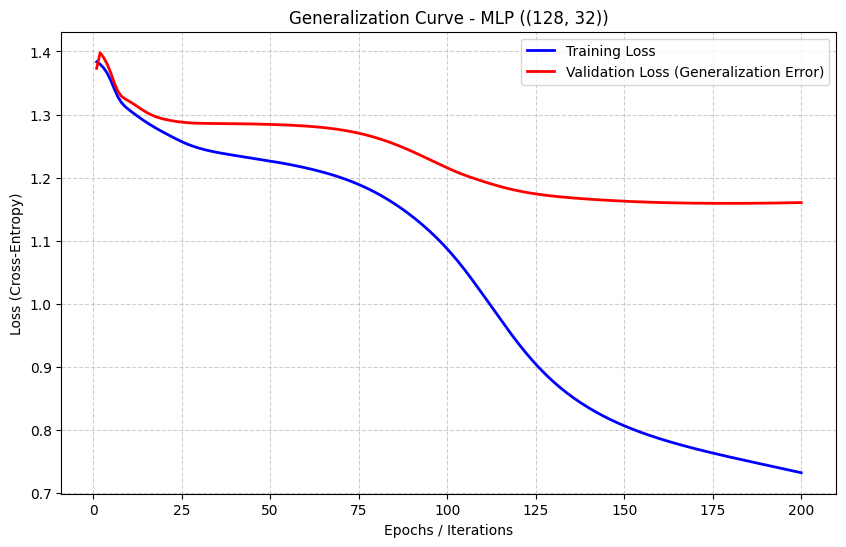

The network does not use early stopping.



In [40]:
# ==========================================
# Generalization Error Plot (Overfitting Check)
# ==========================================

# Split the training data into training and validation sets
X_tr_raw, X_val, y_tr_raw, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Apply ros only to the training data (X_tr_raw)
# this avoids data leakage
X_tr, y_tr = ros.fit_resample(X_tr_raw, y_tr_raw)

print("Generating Generalization Curve...")

# Choose the best model from the grid search to plot the generalization curve

# set early_stopping to False to train for a fixed number of epochs and record the losses at each epoch
plot_params = best_params.copy()
plot_params['early_stopping'] = False

mlp_curve = MLPClassifier(**plot_params, random_state=42)

classes = np.unique(y_train)
epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):
    mlp_curve.partial_fit(X_tr, y_tr, classes=classes)
    train_proba = mlp_curve.predict_proba(X_tr)
    val_proba = mlp_curve.predict_proba(X_val)
    
    train_losses.append(log_loss(y_tr, train_proba, labels=classes))
    val_losses.append(log_loss(y_val, val_proba, labels=classes))

# Generalization Error plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (Generalization Error)', color='red', lw=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Loss (Cross-Entropy)')
plt.title(f'Generalization Curve - MLP ({best_params["hidden_layer_sizes"]})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

if best_params['early_stopping']:
    print("The network uses early stopping to prevent overfitting.\n")
    early_stopping_epoch = np.argmin(val_losses) + 1
    print(f"Early stopping would have occurred at epoch: {early_stopping_epoch}\n")
else:
    print("The network does not use early stopping.\n")


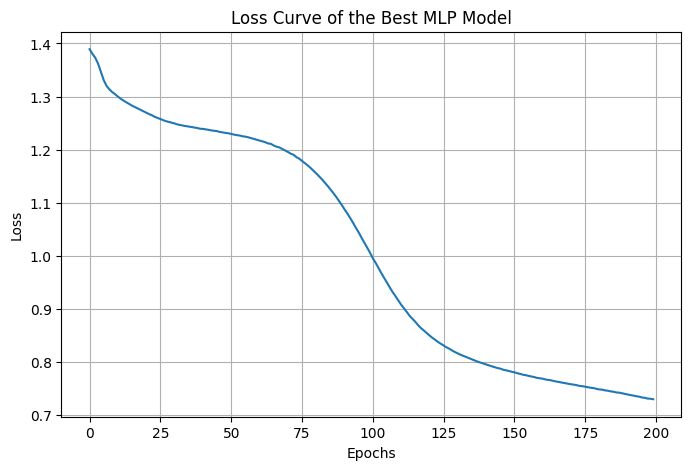

In [43]:
# loss curve of the best model
best_mlp = random_search.best_estimator_
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.named_steps['mlp'].loss_curve_)
plt.title('Loss Curve of the Best MLP Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()

Final evaluation on the test set

Final Evaluation on Test Set...


c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


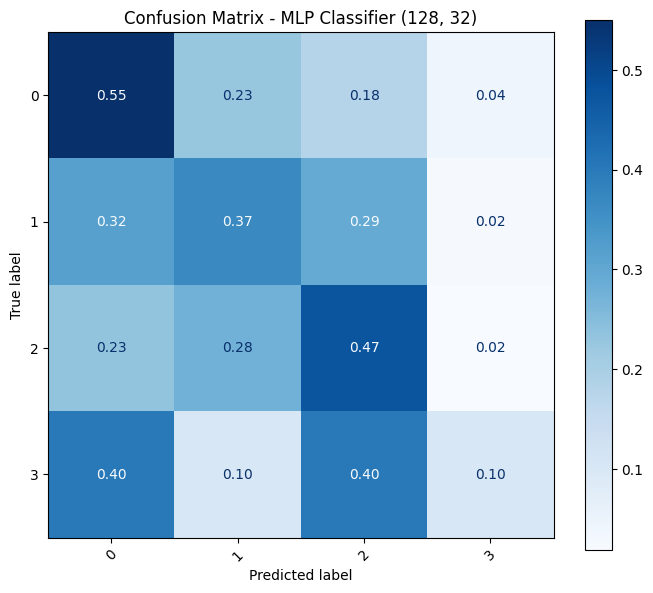

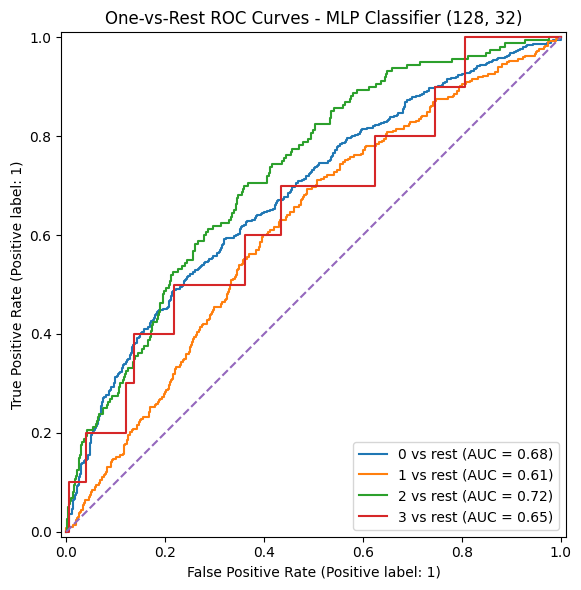

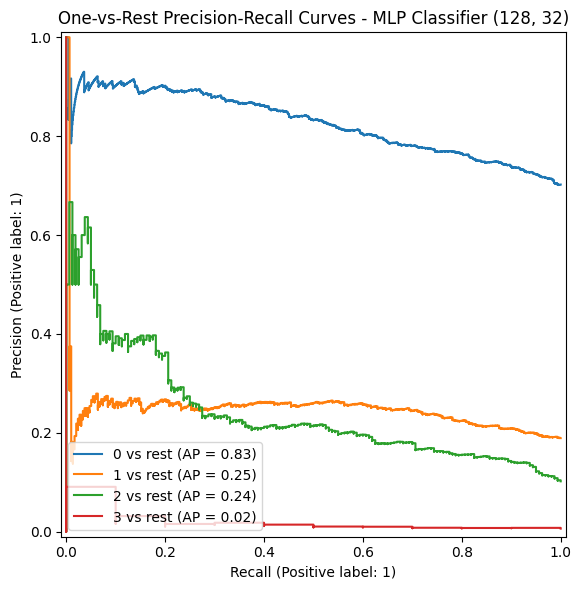


Classification report - MLP Classifier (128, 32)


,precision,recall,f1-score,support
0,0.817814,0.550409,0.657980,1101.000000
1,0.269136,0.367003,0.310541,297.000000
2,0.208219,0.475000,0.289524,160.000000
3,0.017544,0.100000,0.029851,10.000000
accuracy,0.505102,0.505102,0.505102,0.505102
macro avg,0.328178,0.373103,0.321974,1568.000000
weighted avg,0.646580,0.505102,0.550567,1568.000000


In [44]:
# ==========================================
# 3. Final Evaluation on Test Set
# ==========================================
print("Final Evaluation on Test Set...")

# Train the final model on the entire training set (train + validation) using the best hyperparameters found
final_mlp = MLPClassifier(**best_params, random_state=42)
final_mlp.fit(X_train_ros, y_train_ros)

# Evaluation on the test set using the evaluation function
results, report_df = evaluate_classifier(
    model=final_mlp,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP Classifier {best_params['hidden_layer_sizes']}",
    normalize_cm="true"
)

## 2.2 AdaSyn

In [45]:
# ==========================================
# HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
print("Hyperparameter Tuning beginning...")

param_distributions = [
    # adam configuration
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'], # Activation functions
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001, 0.01], # L2 regularization term
        'mlp__learning_rate_init': [0.001, 0.01], # Initial learning rate (not used by 'adam', but we can still include it for consistency)
        'mlp__early_stopping': [True, False], # Eary stopping
        'mlp__max_iter': [150, 200, 300] # epochs
    },
    # SGD solver (Stochastic Gradient Descent)
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['sgd'],
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__learning_rate': ['constant', 'adaptive'], # learning rate schedule for SGD
        'mlp__momentum': [0.9, 0.95, 0.99], # momentum is useful for SGD to accelerate convergence and escape local minima
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    }
]

mlp_base = MLPClassifier(random_state=42)
adasyn = ADASYN(random_state=42, n_neighbors=5) # <--- Inseriamo ADASYN

# We create a pipeline with ADASYN
pipeline_cv_adasyn = ImbPipeline([
    ('adasyn', adasyn), # Adasyn step on the training data during cross-validation
    ('mlp', mlp_base)   # MLP classifier step
])

random_search_adasyn = RandomizedSearchCV(
    estimator=pipeline_cv_adasyn, 
    param_distributions=param_distributions, 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    n_iter=50,
    random_state=42
)

# Fit on the training data (la pipeline applicherà ADASYN fold per fold)
random_search_adasyn.fit(X_train, y_train)

# Estrazione dei parametri migliori puliti dal prefisso
best_params_adasyn = {k.replace('mlp__', ''): v for k, v in random_search_adasyn.best_params_.items()}
print(f"Best Parameters (ADASYN): {best_params_adasyn}\n")
print(f"Best Balanced Accuracy Score from Randomized Search (ADASYN): {random_search_adasyn.best_score_:.4f}\n")

Hyperparameter Tuning beginning...
Best Parameters (ADASYN): {'solver': 'sgd', 'momentum': 0.9, 'max_iter': 200, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 32), 'early_stopping': False, 'alpha': 0.0001, 'activation': 'logistic'}

Best Balanced Accuracy Score from Randomized Search (ADASYN): 0.3597



c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Generating Generalization Curve...


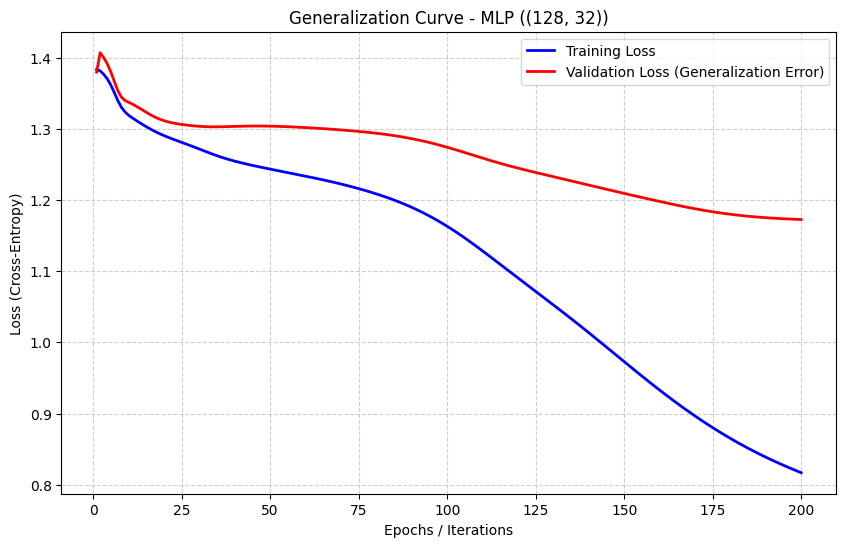

The network does not use early stopping.



In [46]:
# ==========================================
# Generalization Error Plot (Overfitting Check)
# ==========================================

X_tr_ada, X_val, y_tr_ada, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Apply ADASYN only to the training data (X_tr_ada)
X_tr, y_tr = adasyn.fit_resample(X_tr_ada, y_tr_ada)

print("Generating Generalization Curve...")

# Choose the best model from the grid search to plot the generalization curve

# set early_stopping to False to train for a fixed number of epochs and record the losses at each epoch
plot_params = best_params_adasyn.copy()
plot_params['early_stopping'] = False

mlp_curve = MLPClassifier(**plot_params, random_state=42)

classes = np.unique(y_train_adasyn)
epochs = 200
train_losses = []
val_losses = []

# Train the model for a number of epochs and record the training and validation losses at each epoch
for epoch in range(epochs):
    # Perform one epoch of training
    mlp_curve.partial_fit(X_tr, y_tr, classes=classes)
    # Predict probabilities for training and validation sets
    train_proba = mlp_curve.predict_proba(X_tr)
    val_proba = mlp_curve.predict_proba(X_val)
    # Calculate log loss for training and validation sets
    train_losses.append(log_loss(y_tr, train_proba, labels=classes))
    val_losses.append(log_loss(y_val, val_proba, labels=classes))

# Generalization Error plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (Generalization Error)', color='red', lw=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Loss (Cross-Entropy)')
plt.title(f'Generalization Curve - MLP ({plot_params["hidden_layer_sizes"]})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# print if the network uses early stopping or not
if best_params_adasyn['early_stopping']:
    print("The network uses early stopping to prevent overfitting.\n")
    # print the iteration at which early stopping would have occurred based on the validation loss
    early_stopping_epoch = np.argmin(val_losses) + 1
    print(f"Early stopping would have occurred at epoch: {early_stopping_epoch}\n")
else:
    print("The network does not use early stopping.\n")



Final Evaluation on Test Set...


c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


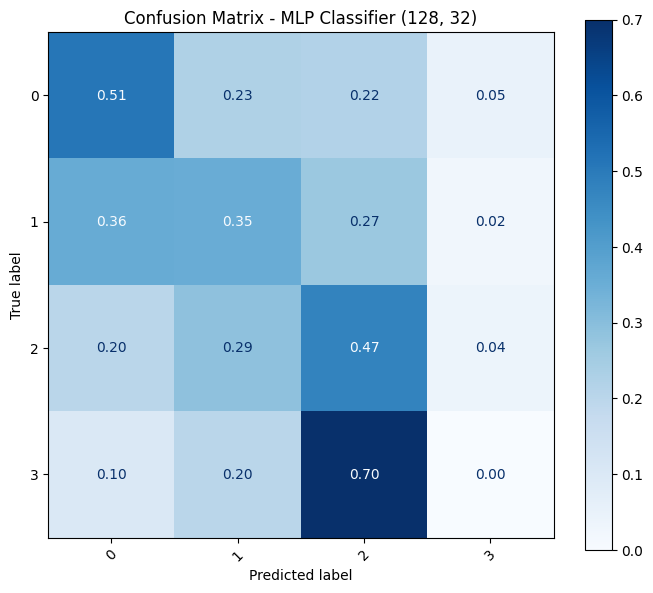

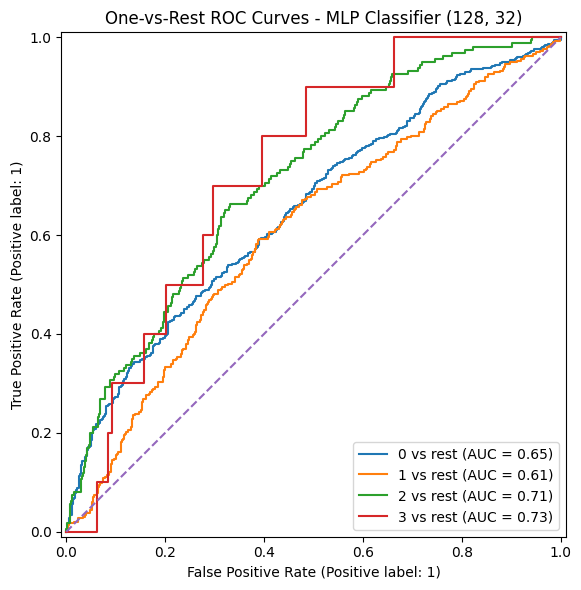

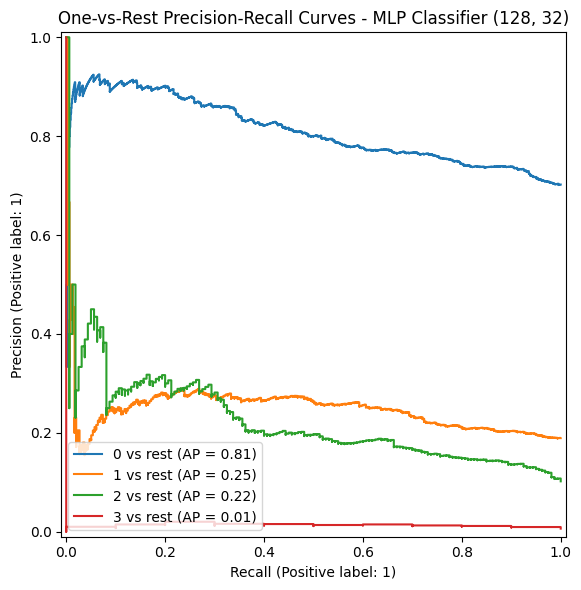


Classification report - MLP Classifier (128, 32)


,precision,recall,f1-score,support
0,0.801144,0.508629,0.622222,1101.000000
1,0.261194,0.353535,0.300429,297.000000
2,0.190000,0.475000,0.271429,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.472577,0.472577,0.472577,0.472577
macro avg,0.313085,0.334291,0.298520,1568.000000
weighted avg,0.631400,0.472577,0.521507,1568.000000


In [47]:
# ==========================================
# 3. Final Evaluation on Test Set
# ==========================================
print("Final Evaluation on Test Set...")

# Train the final model on the entire training set (train + validation) using the best hyperparameters found
final_mlp = MLPClassifier(**best_params_adasyn, random_state=42)
final_mlp.fit(X_train_adasyn, y_train_adasyn)

# Evaluation on the test set using the evaluation function
results, report_df = evaluate_classifier(
    model=final_mlp,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP Classifier {best_params_adasyn['hidden_layer_sizes']}",
    normalize_cm="true"
)

## 2.3 Adasyn + ENN

Hyperparameter Tuning beginning with ADASYN + ENN + MLP...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters found: {'mlp__solver': 'adam', 'mlp__max_iter': 200, 'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__early_stopping': True, 'mlp__alpha': 0.01, 'mlp__activation': 'relu', 'enn__n_neighbors': 7, 'enn__kind_sel': 'all', 'adasyn__n_neighbors': 5}

Best Balanced Accuracy Score from Randomized Search: 0.3326

Final Evaluation on Test Set...


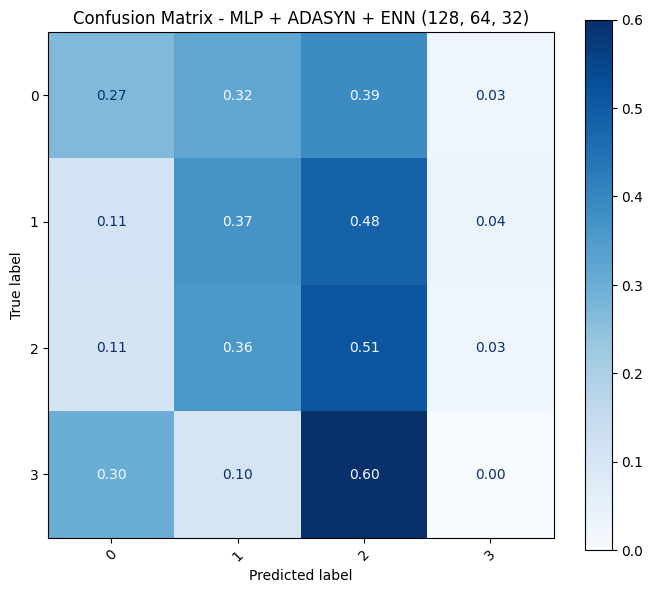

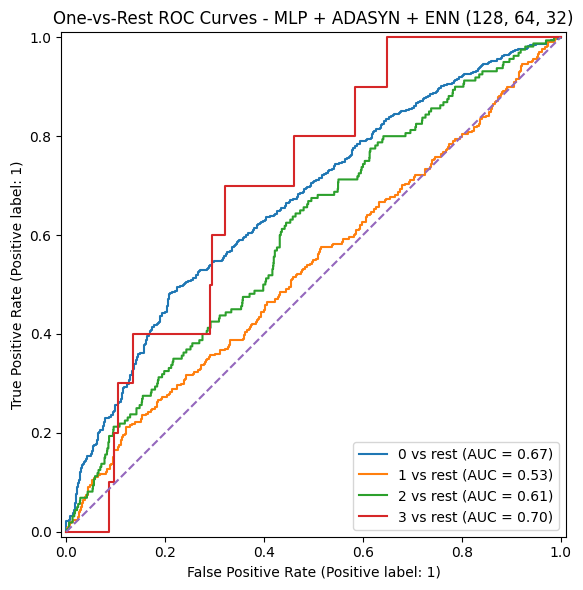

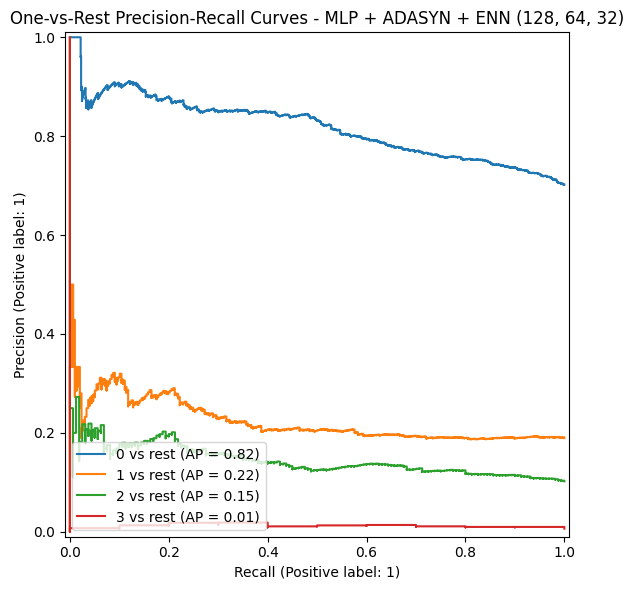


Classification report - MLP + ADASYN + ENN (128, 64, 32)


,precision,recall,f1-score,support
0,0.847701,0.267938,0.407177,1101.000000
1,0.210425,0.367003,0.267485,297.000000
2,0.124620,0.512500,0.200489,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.309949,0.309949,0.309949,0.309949
macro avg,0.295686,0.286860,0.218788,1568.000000
weighted avg,0.647802,0.309949,0.357030,1568.000000


In [37]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# HYPERPARAMETER TUNING WITH HYBRID RESAMPLING (ADASYN + ENN + MLP)
# =========================================================================
print("Hyperparameter Tuning beginning with ADASYN + ENN + MLP...")

# Definiamo la griglia dei parametri. 
# Abbiamo aggiunto i parametri di tuning per ADASYN ('adasyn__') ed ENN ('enn__') in entrambe le configurazioni.
param_distributions = [
    # Configurazione ADAM
    {
        'adasyn__n_neighbors': [3, 5, 7],
        'enn__n_neighbors': [3, 5, 7],
        'enn__kind_sel': ['all', 'mode'],
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    },
    # Configurazione SGD (Stochastic Gradient Descent)
    {
        'adasyn__n_neighbors': [3, 5, 7],
        'enn__n_neighbors': [3, 5, 7],
        'enn__kind_sel': ['all', 'mode'],
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['sgd'],
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__learning_rate': ['constant', 'adaptive'],
        'mlp__momentum': [0.9, 0.95, 0.99],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    }
]

# 1. Istanziamo i due campionatori
adasyn_sampler = ADASYN(random_state=42)
# Impostiamo 'all' perché ENN deve pulire i punti confusi generati da ADASYN su tutte le classi
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# 2. Modello MLP di base
mlp_base = MLPClassifier(random_state=42)

# 3. Costruiamo la Pipeline Ibrida Sequenziale
# L'ordine è tassativo: PRIMA si generano i sintetici (ADASYN), POI si puliscono i confini (ENN), INFINE studia l'MLP
pipeline_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler),
    ('enn', enn_sampler),
    ('mlp', mlp_base)
])

# 4. Avviamo la ricerca casuale sulla Pipeline ibrida
random_search = RandomizedSearchCV(
    estimator=pipeline_hybrid, 
    param_distributions=param_distributions, 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    n_iter=50,                  # Puoi ridurlo a 30 se il calcolo risulta troppo pesante
    random_state=42,
    verbose=1
)

# Il fit eseguirà la catena ADASYN -> ENN -> MLP fold per fold in totale sicurezza
random_search.fit(X_train, y_train)

# Estraiamo i migliori parametri e il punteggio
best_params = random_search.best_params_
print(f"\nBest Parameters found: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


# =========================================================================
# Final Evaluation on Test Set
# =========================================================================
print("Final Evaluation on Test Set...")

# Estraiamo la pipeline vincente (già fittata sull'intero X_train usando la combinazione ottimale)
best_pipeline_model = random_search.best_estimator_

# Otteniamo la dimensione degli hidden layer per il titolo del grafico
chosen_architecture = best_params['mlp__hidden_layer_sizes']

# Valutazione finale sul test set reale sbilanciato
results, report_df = evaluate_classifier(
    model=best_pipeline_model,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP + ADASYN + ENN {chosen_architecture}",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [38]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = data['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (6271, 32), Test size: (1568, 32)
Puoi lanciare la tua RandomizedSearch


In [ ]:
# ==========================================
# HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
print("Hyperparameter Tuning beginning...")

# Definiamo la griglia dei parametri da testare
param_grid = {
    'hidden_layer_sizes': [(128, 64, 32,), (128, 32,), (64, 32,), (10, 10, 10), (100, 100, 100)], # hidden layers dimensions and number of layers
    'alpha': [0.0001, 0.001, 0.01], # L2 regularization term to prevent overfitting
    'learning_rate_init': [0.001, 0.01], # Initial learning rate (if using 'constant' learning rate schedule)
    'learning_rate': ['constant', 'adaptive'], # Learning rate schedule (if using 'sgd' solver)
    'activation': ['relu', 'tanh', 'logistic', 'identity'], # Hidden layer activation function
    'early_stopping': [True, False], # Whether to use early stopping to terminate training when validation score is not improving
    'momentum': [0.9, 0.95, 0.99], # Momentum for gradient descent update (if using 'sgd' solver)
    'solver': ['adam', 'sgd', 'lbfgs'], # Optimizer for weight updates
    'max_iter': [10, 50, 100, 200], # Maximum number of iterations (epochs) to train the model
}

param_distributions = [
    # adam configuration
    {
        'hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'activation': ['relu', 'tanh', 'logistic'], # Activation functions
        'solver': ['adam'], 
        'alpha': [0.0001, 0.001, 0.01], # L2 regularization term
        'learning_rate_init': [0.001, 0.01], # Initial learning rate (not used by 'adam', but we can still include it for consistency)
        'early_stopping': [True, False], # Eary stopping
        'max_iter': [150, 200, 300] # epochs
    },
    # SGD solver (Stochastic Gradient Descent)
    {
        'hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['sgd'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'], # learning rate schedule for SGD
        'momentum': [0.9, 0.95, 0.99], # momentum is useful for SGD to accelerate convergence and escape local minima
        'early_stopping': [True, False],
        'max_iter': [150, 200, 300]
    }
]

mlp_base = MLPClassifier(max_iter=150, random_state=42, early_stopping=False)

# Looks for the configuration that maximizes the balanced accuracy score using 3-fold cross-validation
random_search = RandomizedSearchCV(
    mlp_base, param_distributions=param_distributions, cv=3, scoring='balanced_accuracy', n_jobs=-1, n_iter=50
)

# Fit the grid search to the training data
random_search.fit(X_train, y_train)

# Print the best parameters found by the grid search
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


Hyperparameter Tuning beginning...
Best Parameters: {'solver': 'adam', 'max_iter': 150, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'early_stopping': False, 'alpha': 0.001, 'activation': 'relu'}

Best Balanced Accuracy Score from Randomized Search: 0.4110



Final Evaluation on Test Set...


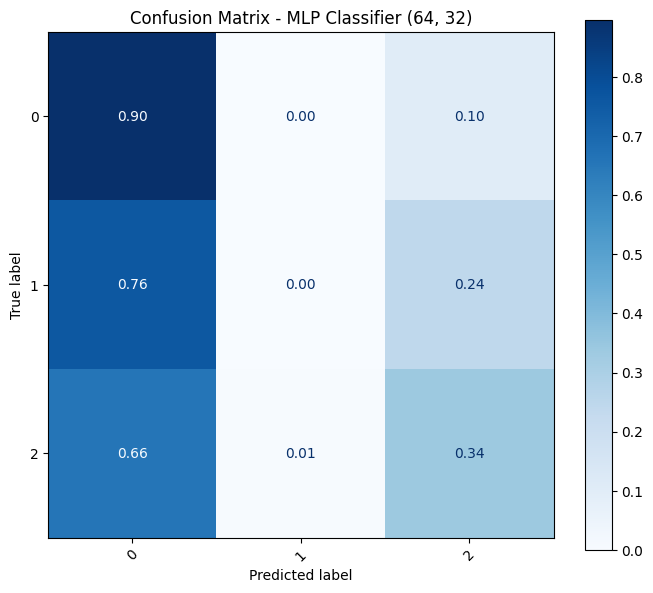

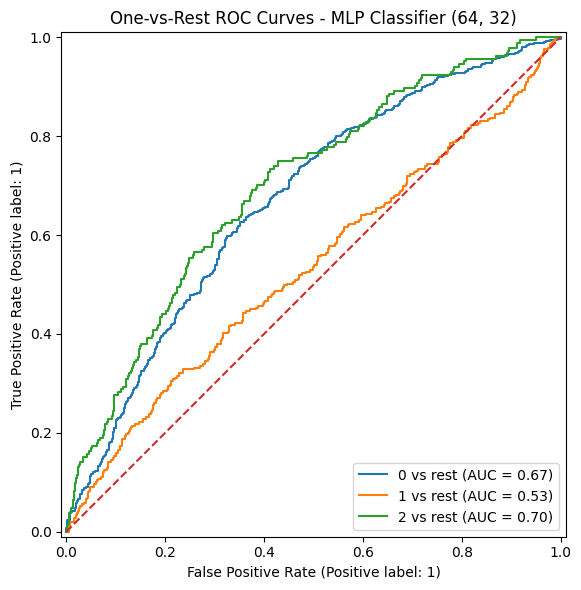

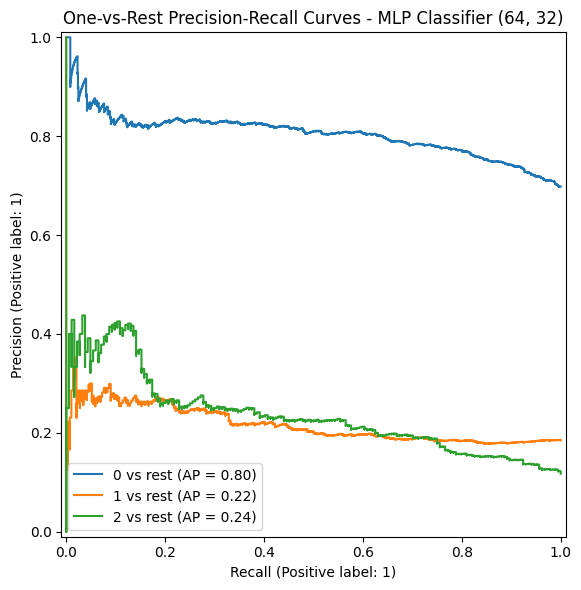


Classification report - MLP Classifier (64, 32)


,precision,recall,f1-score,support
0,0.742814,0.896804,0.812578,1095.000000
1,0.000000,0.000000,0.000000,289.000000
2,0.253061,0.336957,0.289044,184.000000
accuracy,0.665816,0.665816,0.665816,0.665816
macro avg,0.331958,0.411253,0.367207,1568.000000
weighted avg,0.548434,0.665816,0.601375,1568.000000


In [10]:
# ==========================================
# Final Evaluation on Test Set
# ==========================================
print("Final Evaluation on Test Set...")

# Train the final model on the entire training set (train + validation) using the best hyperparameters found
final_mlp = MLPClassifier(**best_params, random_state=42)
final_mlp.fit(X_train, y_train)

# Evaluation on the test set using the evaluation function
results, report_df = evaluate_classifier(
    model=final_mlp,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP Classifier {best_params['hidden_layer_sizes']}",
    normalize_cm="true"
)

## 3 classes, majority undersampled (ENN)

Hyperparameter Tuning beginning with ENN + MLP...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters found: {'mlp__solver': 'adam', 'mlp__max_iter': 150, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 32), 'mlp__early_stopping': False, 'mlp__alpha': 0.01, 'mlp__activation': 'logistic'}

Best Balanced Accuracy Score from Randomized Search: 0.4225

Final Evaluation on Test Set...


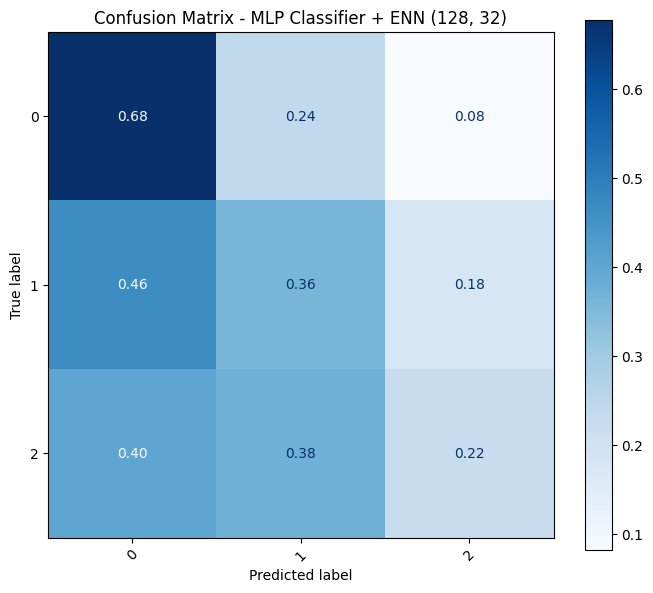

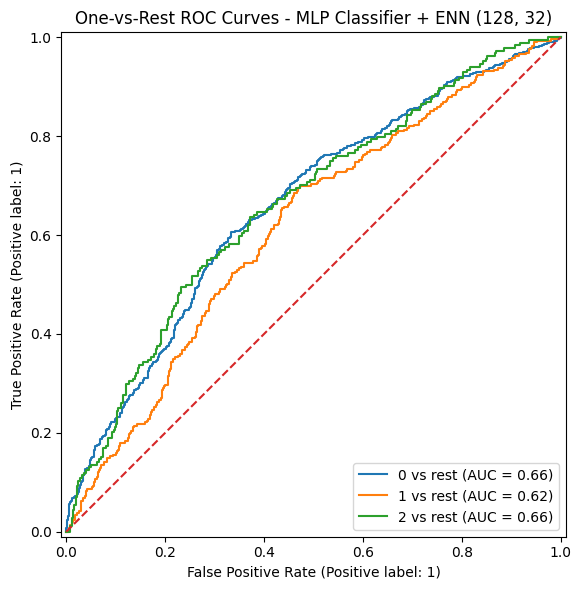

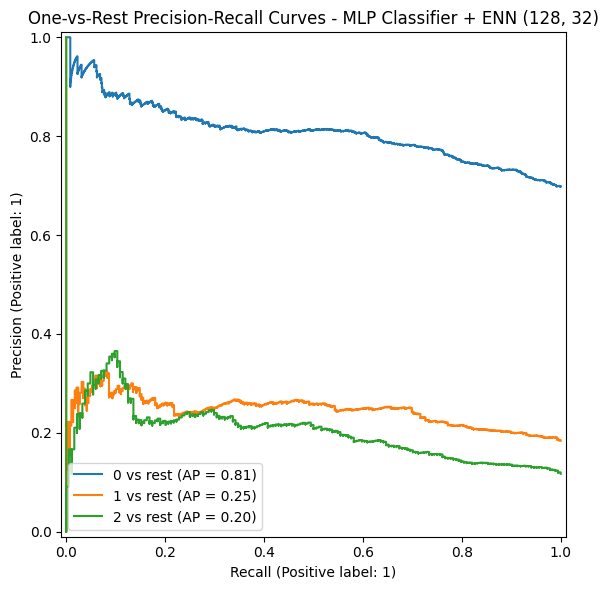


Classification report - MLP Classifier + ENN (128, 32)


,precision,recall,f1-score,support
0,0.781053,0.677626,0.725672,1095.000000
1,0.238532,0.359862,0.286897,289.000000
2,0.225275,0.222826,0.224044,184.000000
accuracy,0.565689,0.565689,0.565689,0.565689
macro avg,0.414953,0.420104,0.412204,1568.000000
weighted avg,0.615841,0.565689,0.585936,1568.000000


In [11]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import EditedNearestNeighbours  
from imblearn.pipeline import Pipeline as ImbPipeline        # Pipeline protetta da Data Leakage

# =========================================================================
# HYPERPARAMETER TUNING WITH ENN UNDERSAMPLING (Randomized Search)
# =========================================================================
print("Hyperparameter Tuning beginning with ENN + MLP...")

# Definiamo la griglia dei parametri. 
# NOTA: Abbiamo aggiunto il prefisso 'mlp__' a ogni parametro per la Pipeline.
param_distributions = [
    # Configurazione ADAM
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    },
    # Configurazione SGD (Stochastic Gradient Descent)
    {
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['sgd'],
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__learning_rate': ['constant', 'adaptive'],
        'mlp__momentum': [0.9, 0.95, 0.99],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    }
]

# Configurazione ENN: ripulisce SOLO la classe maggioritaria (Classe 0)
enn_sampler = EditedNearestNeighbours(sampling_strategy='majority', n_neighbors=5)

# Modello MLP di base
mlp_base = MLPClassifier(random_state=42)

# Costruiamo la Pipeline protetta: prima ENN pulisce i dati del fold di train, poi MLP studia
pipeline_mlp_enn = ImbPipeline([
    ('enn', enn_sampler),
    ('mlp', mlp_base)
])

# Avviamo la ricerca casuale passando la Pipeline invece del singolo modello
random_search = RandomizedSearchCV(
    estimator=pipeline_mlp_enn, 
    param_distributions=param_distributions, 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    n_iter=50,
    random_state=42,
    verbose=1
)

# Il fit applicherà l'ENN fold per fold in modo matematicamente sicuro
random_search.fit(X_train, y_train)

# Estraiamo i migliori parametri e il punteggio
best_params = random_search.best_params_
print(f"\nBest Parameters found: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


# =========================================================================
# Final Evaluation on Test Set
# =========================================================================
print("Final Evaluation on Test Set...")

# NOTA METODOLOGICA: Scikit-learn, al termine della ricerca, riaddestra automaticamente 
# il modello migliore sull'intero dataset (X_train, y_train) applicando anche i passaggi di preprocessing.
# Possiamo estrarre direttamente questo oggetto 'vincente' senza dover fare un fit manuale.
best_pipeline_model = random_search.best_estimator_

# Otteniamo la dimensione degli hidden layer scelti per il titolo del grafico
chosen_architecture = best_params['mlp__hidden_layer_sizes']

# Valutazione finale sul test set reale (immacolato e sbilanciato)
results, report_df = evaluate_classifier(
    model=best_pipeline_model,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP Classifier + ENN {chosen_architecture}",
    normalize_cm="true"
)

## 3 classes, Adasyn + ENN

Hyperparameter Tuning beginning with ADASYN + ENN + MLP...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters found: {'mlp__solver': 'adam', 'mlp__max_iter': 300, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__early_stopping': True, 'mlp__alpha': 0.0001, 'mlp__activation': 'relu', 'enn__n_neighbors': 3, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 5}

Best Balanced Accuracy Score from Randomized Search: 0.3901

Final Evaluation on Test Set...


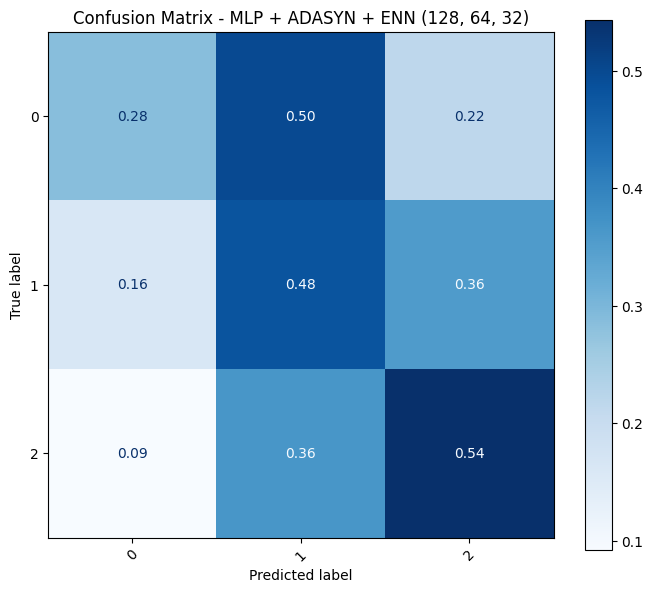

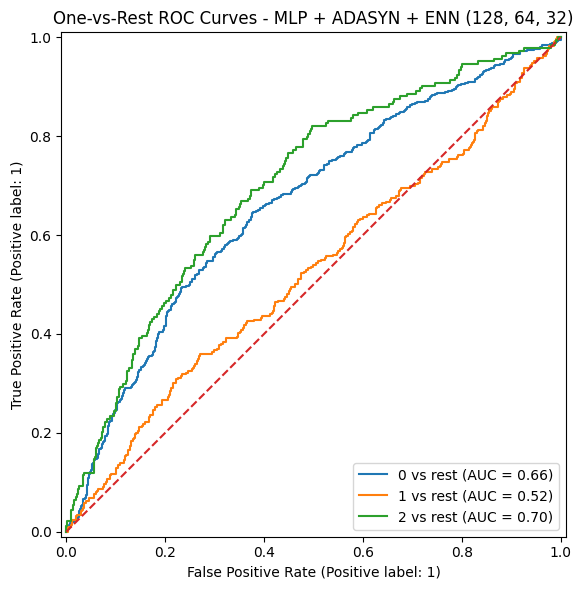

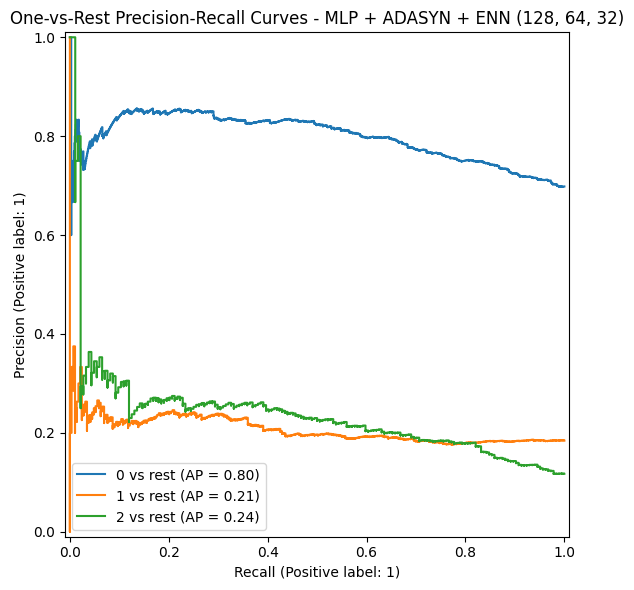


Classification report - MLP + ADASYN + ENN (128, 64, 32)


,precision,recall,f1-score,support
0,0.829787,0.284932,0.424201,1095.000000
1,0.185087,0.480969,0.267308,289.000000
2,0.226757,0.543478,0.320000,184.000000
accuracy,0.351403,0.351403,0.351403,0.351403
macro avg,0.413877,0.436460,0.337170,1568.000000
weighted avg,0.640198,0.351403,0.383056,1568.000000


In [39]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# HYPERPARAMETER TUNING WITH HYBRID RESAMPLING (ADASYN + ENN + MLP)
# =========================================================================
print("Hyperparameter Tuning beginning with ADASYN + ENN + MLP...")

# Definiamo la griglia dei parametri. 
# Abbiamo aggiunto i parametri di tuning per ADASYN ('adasyn__') ed ENN ('enn__') in entrambe le configurazioni.
param_distributions = [
    # Configurazione ADAM
    {
        'adasyn__n_neighbors': [3, 5, 7],
        'enn__n_neighbors': [3, 5, 7],
        'enn__kind_sel': ['all', 'mode'],
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    },
    # Configurazione SGD (Stochastic Gradient Descent)
    {
        'adasyn__n_neighbors': [3, 5, 7],
        'enn__n_neighbors': [3, 5, 7],
        'enn__kind_sel': ['all', 'mode'],
        'mlp__hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100, 100)],
        'mlp__activation': ['relu', 'tanh', 'logistic'],
        'mlp__solver': ['sgd'],
        'mlp__alpha': [0.0001, 0.001, 0.01],
        'mlp__learning_rate_init': [0.001, 0.01],
        'mlp__learning_rate': ['constant', 'adaptive'],
        'mlp__momentum': [0.9, 0.95, 0.99],
        'mlp__early_stopping': [True, False],
        'mlp__max_iter': [150, 200, 300]
    }
]

# 1. Istanziamo i due campionatori
adasyn_sampler = ADASYN(random_state=42)
# Impostiamo 'all' perché ENN deve pulire i punti confusi generati da ADASYN su tutte le classi
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# 2. Modello MLP di base
mlp_base = MLPClassifier(random_state=42)

# 3. Costruiamo la Pipeline Ibrida Sequenziale
# L'ordine è tassativo: PRIMA si generano i sintetici (ADASYN), POI si puliscono i confini (ENN), INFINE studia l'MLP
pipeline_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler),
    ('enn', enn_sampler),
    ('mlp', mlp_base)
])

# 4. Avviamo la ricerca casuale sulla Pipeline ibrida
random_search = RandomizedSearchCV(
    estimator=pipeline_hybrid, 
    param_distributions=param_distributions, 
    cv=3, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    n_iter=50,                  # Puoi ridurlo a 30 se il calcolo risulta troppo pesante
    random_state=42,
    verbose=1
)

# Il fit eseguirà la catena ADASYN -> ENN -> MLP fold per fold in totale sicurezza
random_search.fit(X_train, y_train)

# Estraiamo i migliori parametri e il punteggio
best_params = random_search.best_params_
print(f"\nBest Parameters found: {best_params}\n")
print(f"Best Balanced Accuracy Score from Randomized Search: {random_search.best_score_:.4f}\n")


# =========================================================================
# Final Evaluation on Test Set
# =========================================================================
print("Final Evaluation on Test Set...")

# Estraiamo la pipeline vincente (già fittata sull'intero X_train usando la combinazione ottimale)
best_pipeline_model = random_search.best_estimator_

# Otteniamo la dimensione degli hidden layer per il titolo del grafico
chosen_architecture = best_params['mlp__hidden_layer_sizes']

# Valutazione finale sul test set reale sbilanciato
results, report_df = evaluate_classifier(
    model=best_pipeline_model,
    X_test=X_test,
    y_test=y_test,
    model_name=f"MLP + ADASYN + ENN {chosen_architecture}",
    normalize_cm="true"
)

# Neural Networks (Keras)

4 classes -> ROS used to balance classes

In [ ]:
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from imblearn.over_sampling import RandomOverSampler, ADASYN

# 1. Configurazione parametri della rete
input_dim = X_train.shape[1]  # Numero di feature del tuo dataset
num_classes = len(np.unique(y_train))  # Nel nostro caso: 4

# 2. Costruzione della Rete Neurale Custom
model = keras.Sequential([
    # Input Layer 
    layers.Input(shape=(input_dim,)),
    
    # Primo Blocco Nascosto (Activation: ReLU)
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),  # Stabilizza l'addestramento -> normalizza le attivazioni del layer precedente
    layers.Dropout(0.3),          # Spegne il 30% dei neuroni per prevenire l'overfitting
    
    # Secondo Blocco Nascosto (Activation: Tanh - diversificata)
    layers.Dense(64, activation='tanh'),
    layers.BatchNormalization(), # Stabilizza l'addestramento
    layers.Dropout(0.3), # Spegne il 30% dei neuroni per prevenire l'overfitting
    
    # Output Layer (Activation: Softmax per classificazione multiclasse)
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compilazione del Modello
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), # Usiamo Adam per l'ottimizzazione
    loss='sparse_categorical_crossentropy',  # Ottima per label interi (0, 1, 2, 3)
    metrics=['accuracy']
)

model.summary()  # Mostra la struttura della rete e il numero di parametri

# 4. Configurazione Early Stopping reale
# Si ferma se la validation loss non migliora per 15 epoche e ripristina i pesi migliori
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

# 5. Addestramento (Usiamo il dataset oversamplato ROS o ADASYN)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train) # Oppure usa X_train_adasyn, y_train_adasyn per ADASYN

print("Training Keras Neural Network...")
history = model.fit(
    X_train_ros, y_train_ros,
    validation_split=0.2,  # Estrae automaticamente un validation set interno per il controllo
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,508 (52.77 KB)

 Trainable params: 13,124 (51.27 KB)

 Non-trainable params: 384 (1.50 KB)

Training Keras Neural Network...
Epoch 1/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3924 - loss: 1.4036 - val_accuracy: 0.0437 - val_loss: 1.8381
Epoch 2/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4450 - loss: 1.1796 - val_accuracy: 0.2877 - val_loss: 1.5512
Epoch 3/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4781 - loss: 1.1125 - val_accuracy: 0.4540 - val_loss: 1.3053
Epoch 4/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4944 - loss: 1.0732 - val_accuracy: 0.6074 - val_loss: 0.9097
Epoch 5/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5129 - loss: 1.0391 - val_accuracy: 0.7643 - val_loss: 0.7408
Epoch 6/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5304 - loss: 1.0012 - val_accuracy: 0.8789 - val_loss: 0.4541
Epoch 7/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5445 - loss: 0.9790 - val_accuracy: 0.9246 - val_loss: 0.3445
Epoch 8/150
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy:

Generalization Error Plot

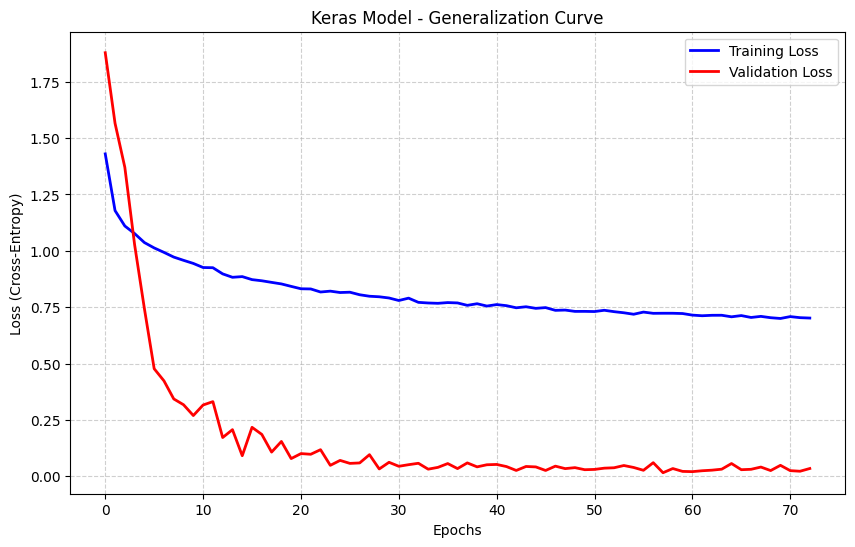

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Keras Model - Generalization Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Keras NN performance on the test set

In [22]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize


def evaluate_predictions(
    y_test,
    y_pred,
    y_score=None,
    model_name="Model",
    labels=None,
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm=None,
    return_report=True
):
    """
    Evaluate any classifier using precomputed predictions and scores.
    Perfect for Sklearn, PyTorch, Keras, or XGBoost.
    """
    if labels is None:
        labels = np.unique(y_test)

    # All aggregate metrics remain identical
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        f"precision_{average}": precision_score(y_test, y_pred, labels=labels, average=average, zero_division=0),
        f"recall_{average}": recall_score(y_test, y_pred, labels=labels, average=average, zero_division=0),
        f"f1_{average}": f1_score(y_test, y_pred, labels=labels, average=average, zero_division=0),
        "precision_macro": precision_score(y_test, y_pred, labels=labels, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, labels=labels, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, labels=labels, average="macro", zero_division=0),
    }

    report_df = pd.DataFrame(
        classification_report(y_test, y_pred, labels=labels, output_dict=True, zero_division=0)
    ).T

    if plot_confusion:
        cm = confusion_matrix(y_test, y_pred, labels=labels, normalize=normalize_cm)
        fig, ax = plt.subplots(figsize=(7, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, values_format=".2f" if normalize_cm else "d", cmap="Blues")
        ax.set_title(f"Confusion Matrix - {model_name}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Evaluation of ROC and PR curves using the passed y_score
    if y_score is not None and len(labels) > 2:
        y_test_bin = label_binarize(y_test, classes=labels)

        try:
            results["roc_auc_ovr_weighted"] = roc_auc_score(y_test_bin, y_score, average="weighted", multi_class="ovr")
            results["roc_auc_ovr_macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
        except Exception:
            results["roc_auc_ovr_weighted"] = np.nan
            results["roc_auc_ovr_macro"] = np.nan

        if plot_roc:
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, cls in enumerate(labels):
                RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i], name=f"{cls} vs rest", ax=ax)
            ax.plot([0, 1], [0, 1], linestyle="--")
            ax.set_title(f"One-vs-Rest ROC Curves - {model_name}")
            plt.tight_layout()
            plt.show()

        if plot_pr:
            fig, ax = plt.subplots(figsize=(7, 6))

            for i, cls in enumerate(labels):
                # CORRETTO: rimosso il parametro 'i' in mezzo
                PrecisionRecallDisplay.from_predictions(
                    y_test_bin[:, i],
                    y_score[:, i],  # <--- Prima c'era scritto: i, y_score[:, i]
                    name=f"{cls} vs rest",
                    ax=ax
                )

            ax.set_title(f"One-vs-Rest Precision-Recall Curves - {model_name}")
            plt.tight_layout()
            plt.show()

    elif y_score is not None and len(labels) == 2:
        # (L'approccio binario esistente rimane qui invariato...)
        pass
    else:
        results["roc_auc_ovr_weighted"] = np.nan
        results["roc_auc_ovr_macro"] = np.nan
        print(f"[Warning] {model_name}: no y_score provided. ROC/PR curves skipped.")

    if return_report:
        print(f"\nClassification report - {model_name}")
        display(report_df)

    return results, report_df

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


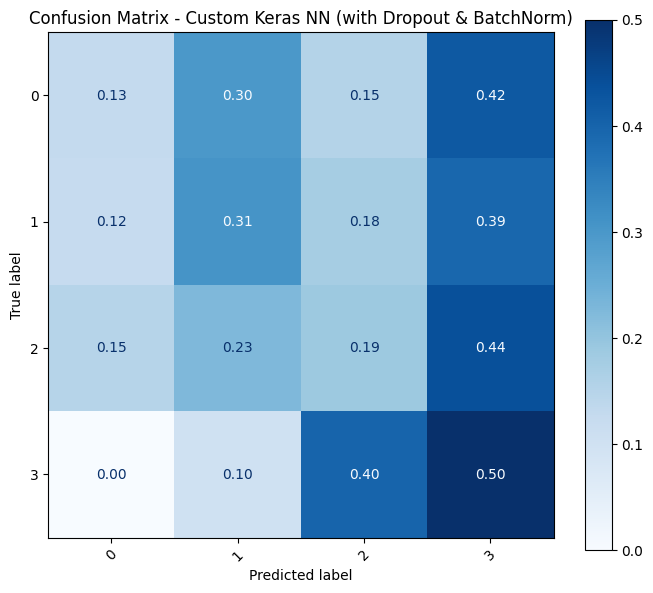

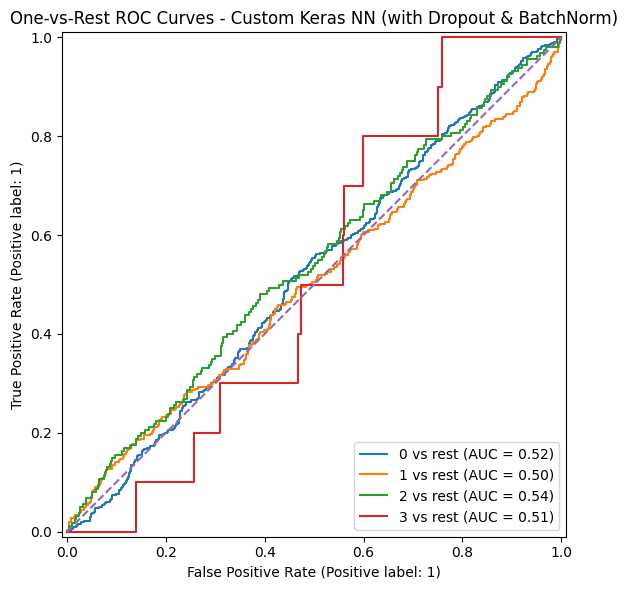

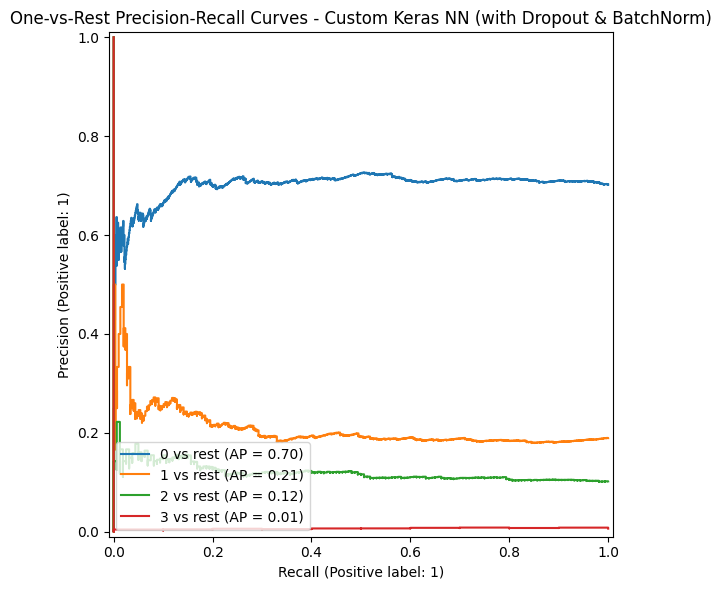


Classification report - Custom Keras NN (with Dropout & BatchNorm)


,precision,recall,f1-score,support
0,0.696517,0.127157,0.215054,1101.000000
1,0.199561,0.306397,0.241700,297.000000
2,0.117647,0.187500,0.144578,160.000000
3,0.007622,0.500000,0.015015,10.000000
accuracy,0.169643,0.169643,0.169643,0.169643
macro avg,0.255337,0.280264,0.154087,1568.000000
weighted avg,0.538925,0.169643,0.211634,1568.000000


In [23]:
# 1. Otteniamo i punteggi (le probabilità della Softmax) per il Test Set reale
y_score_keras = model.predict(X_test)

# 2. Otteniamo la classe predetta prendendo l'indice con la probabilità massima
y_pred_keras = np.argmax(y_score_keras, axis=1)

# 3. Lanciamo la funzione di valutazione (Usa la versione universale basata sui vettori)
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Custom Keras NN (with Dropout & BatchNorm)",
    normalize_cm="true"
)

4 classes -> weighted matrix instead of ros to balance classes

In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================================================================
# 1. Calcolo automatico del dizionario dei pesi
# ATTENZIONE: Va calcolato sul y_train ORIGINALE sbilanciato!
# =========================================================================
class_labels = np.unique(y_train)

calculated_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train
)

# Trasformiamo l'array in un dizionario {classe: peso} richiesto da Keras
class_weight_dict = dict(zip(class_labels, calculated_weights))

print("Dizionario class_weight calcolato:")
for cls, weight in class_weight_dict.items():
    print(f"  Classe {cls}: {weight:.4f}")

# =========================================================================
# 2. Addestramento del Modello in Keras
# =========================================================================
print("\nTraining Keras Neural Network with Class Weights...")

history = model.fit(
    X_train, y_train,          # <--- NOTA: Usiamo X_train e y_train ORIGINALI (sbilanciati)
    validation_split=0.2,      # Estrae il validation set dall'originale sbilanciato
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict, # <--- APPLICHIAMO IL DIZIONARIO QUI
    verbose=1
)

Dizionario class_weight calcolato:
  Classe 0: 0.3583
  Classe 1: 1.3668
  Classe 2: 2.2853
  Classe 3: 24.8849

Training Keras Neural Network with Class Weights...
Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5474 - loss: 0.7027 - val_accuracy: 0.7100 - val_loss: 0.6773
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5399 - loss: 0.8731 - val_accuracy: 0.6574 - val_loss: 0.8213
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5562 - loss: 0.8369 - val_accuracy: 0.6518 - val_loss: 0.7892
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5508 - loss: 0.7897 - val_accuracy: 0.6382 - val_loss: 0.8083
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5604 - loss: 0.7741 - val_accuracy: 0.6414 - val_loss: 0.8181
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5425 - loss: 0.7601 - val_accuracy: 0.6390 - val_loss: 0.8205
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accura

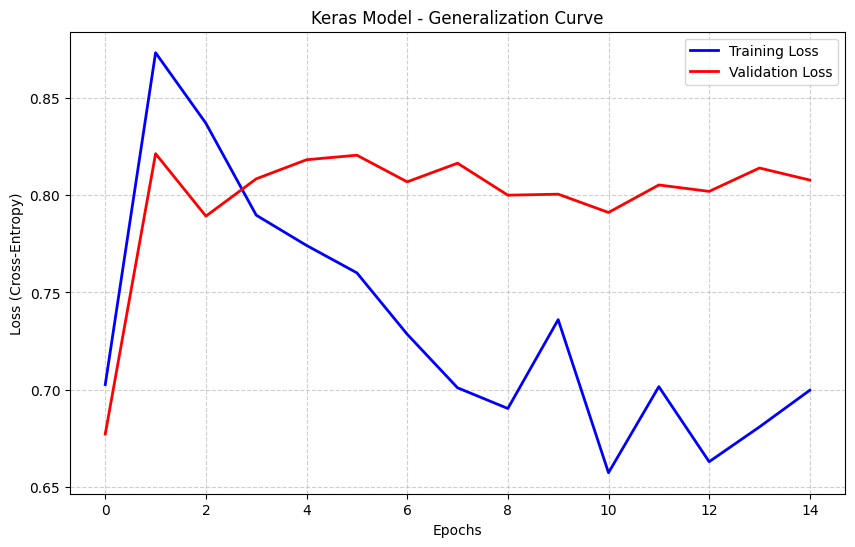

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Keras Model - Generalization Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


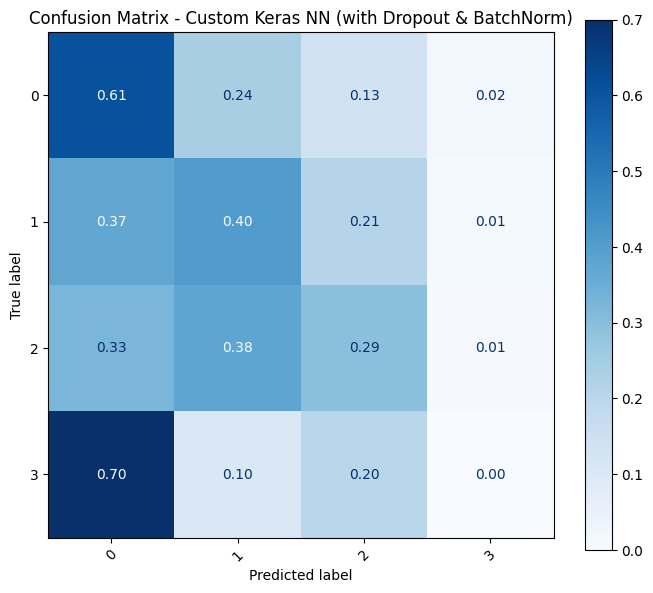

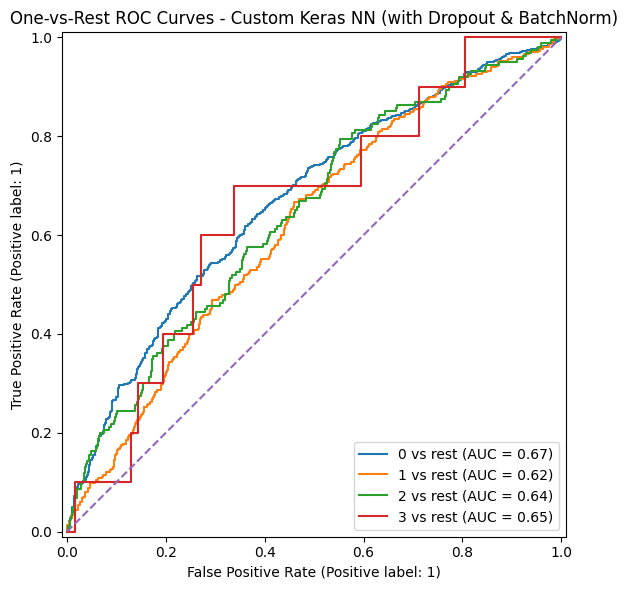

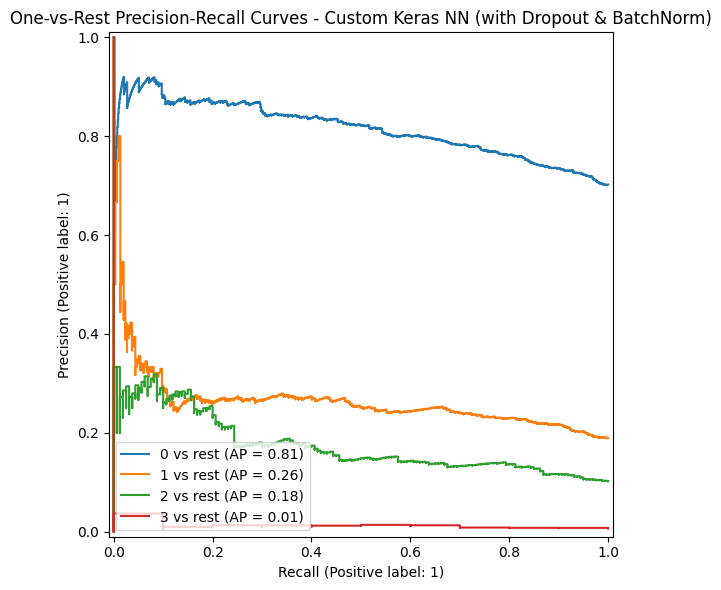


Classification report - Custom Keras NN (with Dropout & BatchNorm)


,precision,recall,f1-score,support
0,0.798339,0.611262,0.692387,1101.000000
1,0.269663,0.404040,0.323450,297.000000
2,0.182879,0.293750,0.225420,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.535714,0.535714,0.535714,0.535714
macro avg,0.312720,0.327263,0.310314,1568.000000
weighted avg,0.630307,0.535714,0.570440,1568.000000


In [28]:
# 1. Otteniamo i punteggi (le probabilità della Softmax) per il Test Set reale
y_score_keras = model.predict(X_test)

# 2. Otteniamo la classe predetta prendendo l'indice con la probabilità massima
y_pred_keras = np.argmax(y_score_keras, axis=1)

# 3. Lanciamo la funzione di valutazione (Usa la versione universale basata sui vettori)
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Custom Keras NN (with Dropout & BatchNorm)",
    normalize_cm="true"
)

4 classes -> lowering learning rate and improving patience

In [32]:
from sklearn.utils.class_weight import compute_class_weight

# =========================================================================
# 1. Calcolo automatico dei pesi sui DATI ORIGINALI SBILANCIATI
# =========================================================================
# Assicurati di usare X_train e y_train originali, NON X_train_ros
class_labels = np.unique(y_train)

calculated_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train
)

class_weight_dict = dict(zip(class_labels, calculated_weights))

print("Dizionario class_weight corretto (calcolato su dati originali):")
for cls, weight in class_weight_dict.items():
    print(f"  Classe {cls} (Label Matrix): {weight:.4f}")

# =========================================================================
# 2. Modifica ARCHITETTURA (Abbassiamo Learning Rate e Alziamo Patience)
# =========================================================================

# Ricompiliamo il modello modificando l'ottimizzatore
# Abbassiamo il Learning Rate di un ordine di grandezza (da 0.001 a 0.0001)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), # <--- MODIFICA CHIAVE
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Estendiamo la patience dell'Early Stopping.
# Con un LR basso e class weights, la rete ha bisogno di più tempo per scendere
# senza essere fermata troppo presto.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=30, # <--- MODIFICA CHIAVE
    restore_best_weights=True
)

# =========================================================================
# 3. Addestramento "Puro" (Senza Oversampling)
# =========================================================================
print("\nTraining Keras NN with corrected methodology...")

history = model.fit(
    X_train, y_train,         # <--- DATI ORIGINALI SBILANCIATI
    validation_split=0.2,
    epochs=200,               # Alziamo le epoche massime visto il LR basso
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict, # Applicazione pesi
    verbose=1
)

Dizionario class_weight corretto (calcolato su dati originali):
  Classe 0 (Label Matrix): 0.3583
  Classe 1 (Label Matrix): 1.3668
  Classe 2 (Label Matrix): 2.2853
  Classe 3 (Label Matrix): 24.8849

Training Keras NN with corrected methodology...
Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5616 - loss: 0.7802 - val_accuracy: 0.6861 - val_loss: 0.7167
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5726 - loss: 0.7341 - val_accuracy: 0.6829 - val_loss: 0.7243
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5664 - loss: 0.7097 - val_accuracy: 0.6853 - val_loss: 0.7208
Epoch 4/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5712 - loss: 0.6846 - val_accuracy: 0.6837 - val_loss: 0.7252
Epoch 5/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5758 - loss: 0.6709 - val_accuracy: 0.6861 - val_loss: 0.7222
Epoch 6/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5736 - loss: 0.6655 - val_accuracy: 0

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


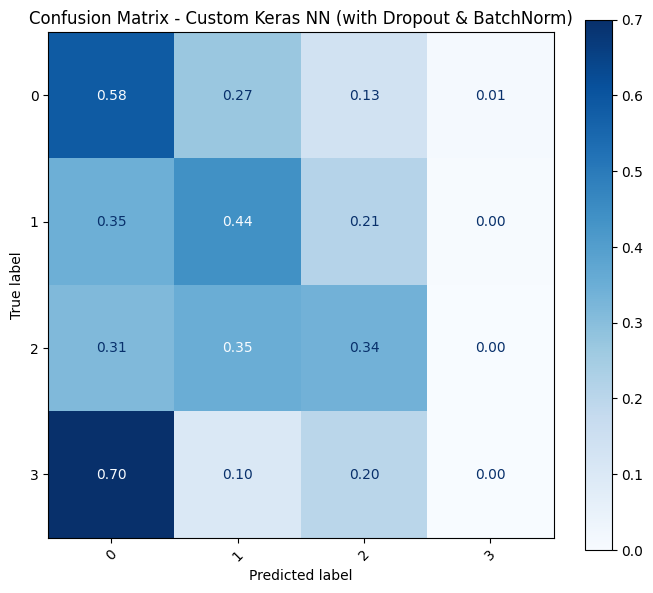

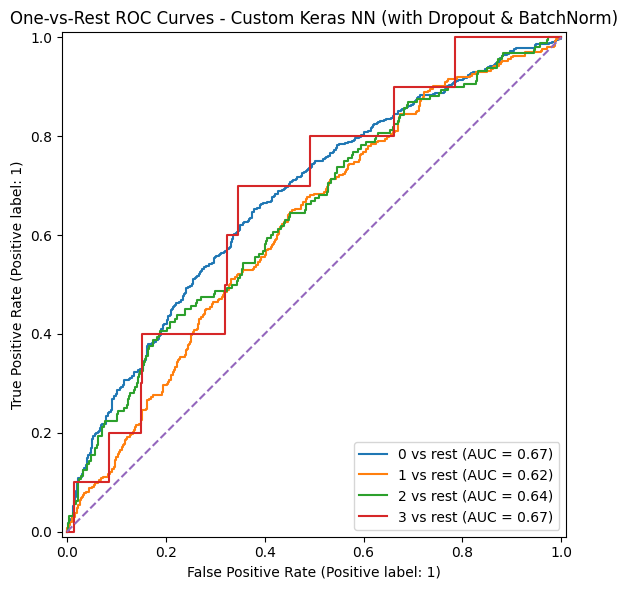

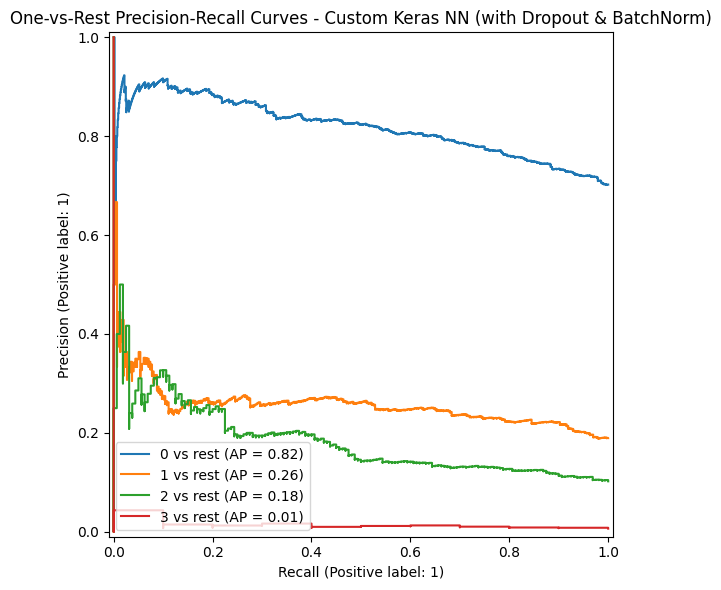


Classification report - Custom Keras NN (with Dropout & BatchNorm)


,precision,recall,f1-score,support
0,0.800995,0.584923,0.676115,1101.000000
1,0.268041,0.437710,0.332481,297.000000
2,0.202247,0.337500,0.252927,160.000000
3,0.000000,0.000000,0.000000,10.000000
accuracy,0.528061,0.528061,0.528061,0.528061
macro avg,0.317821,0.340033,0.315381,1568.000000
weighted avg,0.633841,0.528061,0.563532,1568.000000


In [33]:
# 1. Otteniamo i punteggi (le probabilità della Softmax) per il Test Set reale
y_score_keras = model.predict(X_test)

# 2. Otteniamo la classe predetta prendendo l'indice con la probabilità massima
y_pred_keras = np.argmax(y_score_keras, axis=1)

# 3. Lanciamo la funzione di valutazione (Usa la versione universale basata sui vettori)
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Custom Keras NN (with Dropout & BatchNorm)",
    normalize_cm="true"
)

# **Performances are poor due to the high class imbalance!**

## Keras -> 3 classes problem

In [7]:
# Uniamo la classe 3 (la più piccola) dentro la classe 2
# Se i tuoi dati sono in un array numpy, trasformali temporaneamente o usa le funzioni numpy
# Qui assumiamo che y sia una colonna Pandas (es. df_clean['sii'])

y_clean_3classes = y.replace({3: 2})

# Verifica la nuova distribuzione
from collections import Counter
print("Nuova distribuzione delle 3 classi:")
print(Counter(y_clean_3classes))
# Dovresti vedere: {0: 5476, 1: 1444, 2: 919}

Nuova distribuzione delle 3 classi:
Counter({0: 5476, 1: 1444, 2: 919})


3 classes -> weighted matrix approach

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Nuovo train/test split stratificato sulle 3 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# Ricalcoliamo i pesi per le 3 classi sui dati di train originali
class_labels = np.unique(y_train)
calculated_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train
)
class_weight_dict = dict(zip(class_labels, calculated_weights))

print("\nNuovo dizionario class_weight per 3 classi:")
for cls, weight in class_weight_dict.items():
    print(f"  Classe {cls}: {weight:.4f}")


Nuovo dizionario class_weight per 3 classi:
  Classe 0: 0.4771
  Classe 1: 1.8098
  Classe 2: 2.8440


In [ ]:
input_dim = X_train.shape[1]
num_classes = 3  # <--- CAMBIATO A 3 CLASSI

model_3cl = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='tanh'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output layer calibrato sulle 3 nuove macro-classi
    layers.Dense(num_classes, activation='softmax')
])

model_3cl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

# Addestramento sulle 3 classi
history = model_3cl.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict, # Durante l'addestramento, applichiamo i pesi calcolati per le 3 classi per bilanciare l'influenza di ciascuna classe
    verbose=1
)

Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3443 - loss: 1.5262 - val_accuracy: 0.1681 - val_loss: 1.7996
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3776 - loss: 1.4187 - val_accuracy: 0.3649 - val_loss: 1.3037
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3880 - loss: 1.4157 - val_accuracy: 0.3649 - val_loss: 1.2152
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3780 - loss: 1.3715 - val_accuracy: 0.4311 - val_loss: 1.1876
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3842 - loss: 1.3682 - val_accuracy: 0.4367 - val_loss: 1.1673
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3937 - loss: 1.3338 - val_accuracy: 0.5203 - val_loss: 1.1169
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3906 - loss: 1.3198 - val_accuracy: 0.4908 - val_loss: 1.1418
Epoch 8/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3838 - loss: 1.3034 - val_acc

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


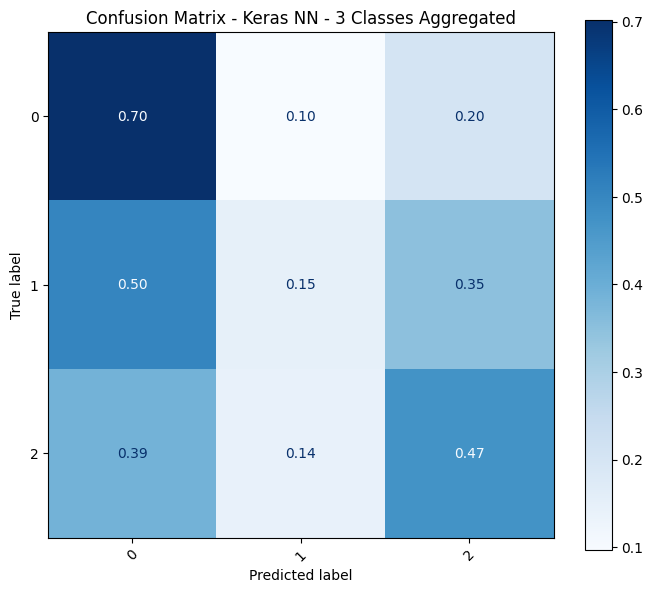

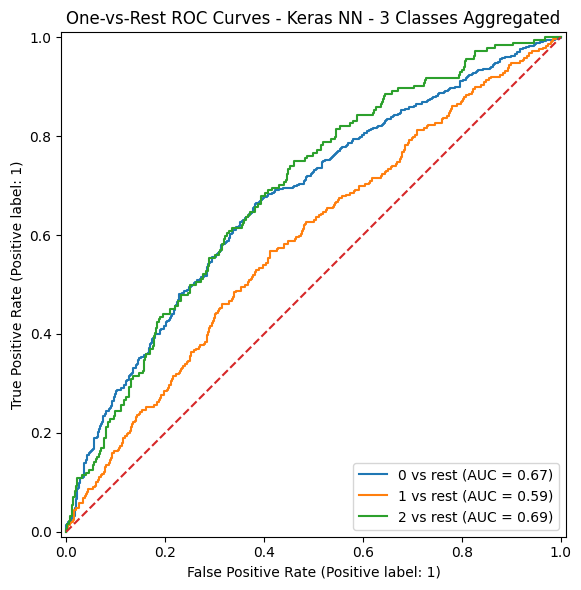

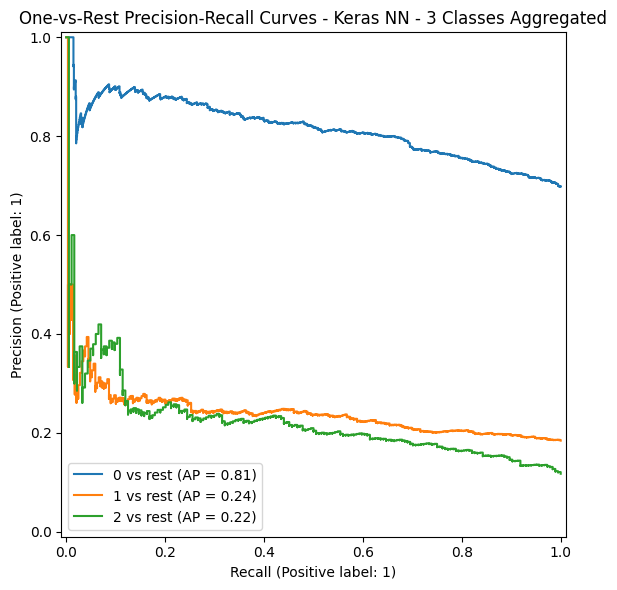


Classification report - Keras NN - 3 Classes Aggregated


,precision,recall,f1-score,support
0,0.780711,0.702283,0.739423,1095.000000
1,0.245714,0.148789,0.185345,289.000000
2,0.213235,0.472826,0.293919,184.000000
accuracy,0.573342,0.573342,0.573342,0.573342
macro avg,0.413220,0.441299,0.406229,1568.000000
weighted avg,0.615513,0.573342,0.585022,1568.000000


In [38]:
# 1. Predizioni sul test set a 3 classi
y_score_keras = model_3cl.predict(X_test)
y_pred_keras = np.argmax(y_score_keras, axis=1)

# 2. Chiamata alla funzione di valutazione grafica
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Keras NN - 3 Classes Aggregated",
    normalize_cm="true"
)

3 classes -> Random Oversampling

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# =========================================================================
# 1. SPLIT E APPLICAZIONE ROS (Protezione da Data Leakage)
# =========================================================================
# Dividiamo X_train e y_train (a 3 classi) in Train stretto e Validation puro
X_tr_raw, X_val, y_tr_raw, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Distribuzione pre-ROS:", Counter(y_tr_raw))

# Applichiamo ROS solo ai dati di addestramento stretti
ros = RandomOverSampler(random_state=42)
X_tr_ros, y_tr_ros = ros.fit_resample(X_tr_raw, y_tr_raw)

print("Distribuzione post-ROS (Train Perfettamente Bilanciato):", Counter(y_tr_ros))


Distribuzione pre-ROS: Counter({0: 3499, 1: 918, 2: 549, 3: 50})
Distribuzione post-ROS (Train Perfettamente Bilanciato): Counter({1: 3499, 0: 3499, 2: 3499, 3: 3499})


In [ ]:

# =========================================================================
# 2. ARCHITETTURA DELLA RETE NEURALE STABILIZZATA
# =========================================================================
input_dim = X_tr_ros.shape[1]
num_classes = 3

model_ros = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    # Primo Blocco (ReLU + L2 + BatchNorm + Dropout)
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Secondo Blocco (Tanh + L2 + BatchNorm + Dropout)
    layers.Dense(64, activation='tanh', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output Layer (Softmax)
    layers.Dense(num_classes, activation='softmax')
])

# Compilazione con Learning Rate iniziale prudente
model_ros.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks per il controllo del training
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# =========================================================================
# 3. ADDESTRAMENTO (Batch Size a 64 per stabilizzare i gradienti)
# =========================================================================
print("\nTraining Keras NN with ROS...")
history = model_ros.fit(
    X_tr_ros, y_tr_ros,
    validation_data=(X_val, y_val), # Validazione sui dati reali non alterati
    epochs=150,
    batch_size=64,                  # Smorza ulteriormente le oscillazioni
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

In [ ]:

# =========================================================================
# 2. ARCHITETTURA DELLA RETE NEURALE STABILIZZATA
# =========================================================================
input_dim = X_tr_ros.shape[1]
num_classes = 3

model_ros = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    # Primo Blocco (ReLU + L2 + BatchNorm + Dropout)
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Secondo Blocco (Tanh + L2 + BatchNorm + Dropout)
    layers.Dense(64, activation='tanh', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output Layer (Softmax)
    layers.Dense(num_classes, activation='softmax')
])

# Compilazione con Learning Rate iniziale prudente
model_ros.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks per il controllo del training
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# =========================================================================
# 3. ADDESTRAMENTO (Batch Size a 64 per stabilizzare i gradienti)
# =========================================================================
print("\nTraining Keras NN with ROS...")
history = model_ros.fit(
    X_tr_ros, y_tr_ros,
    validation_data=(X_val, y_val), # Validazione sui dati reali non alterati
    epochs=150,
    batch_size=64,                  # Smorza ulteriormente le oscillazioni
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

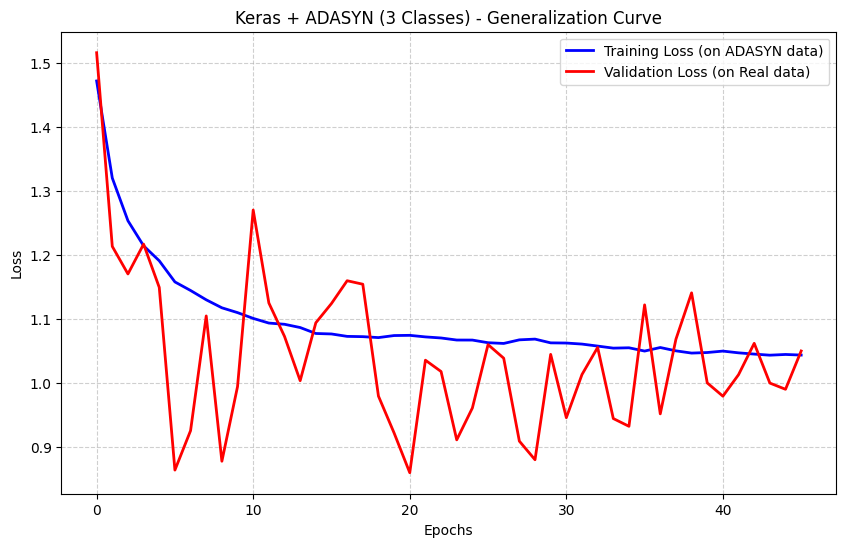

In [50]:

# =========================================================================
# 4. PLOT DELLA CURVA DI GENERALIZZAZIONE
# =========================================================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (on ADASYN data)', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss (on Real data)', color='red', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Keras + ADASYN (3 Classes) - Generalization Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



Final Evaluation on Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


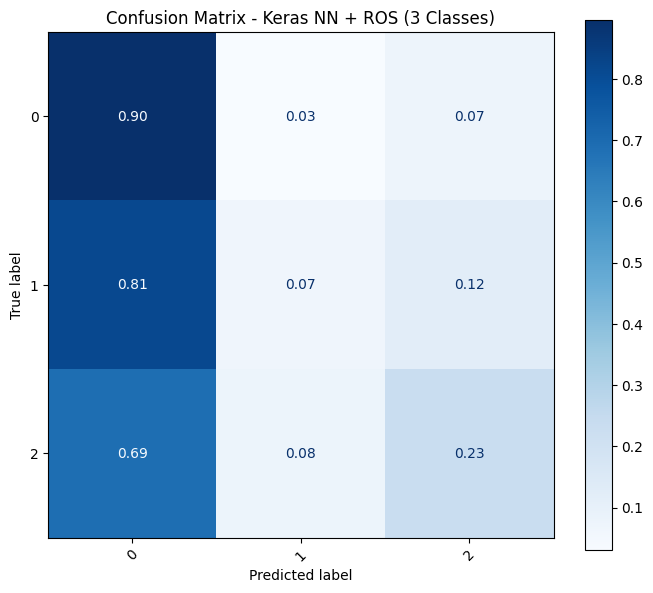

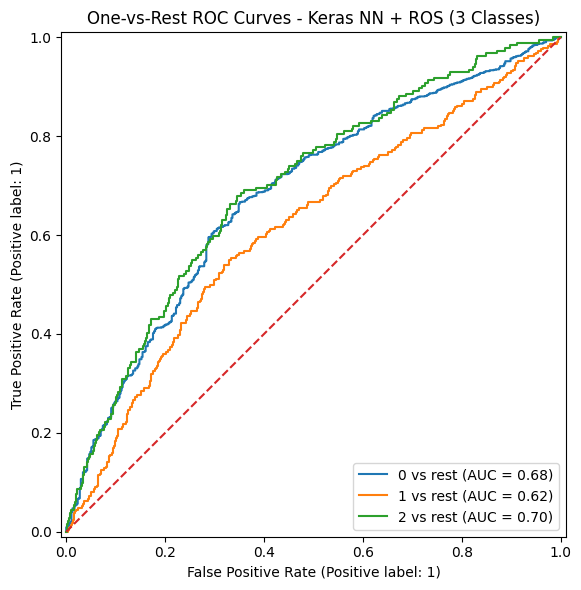

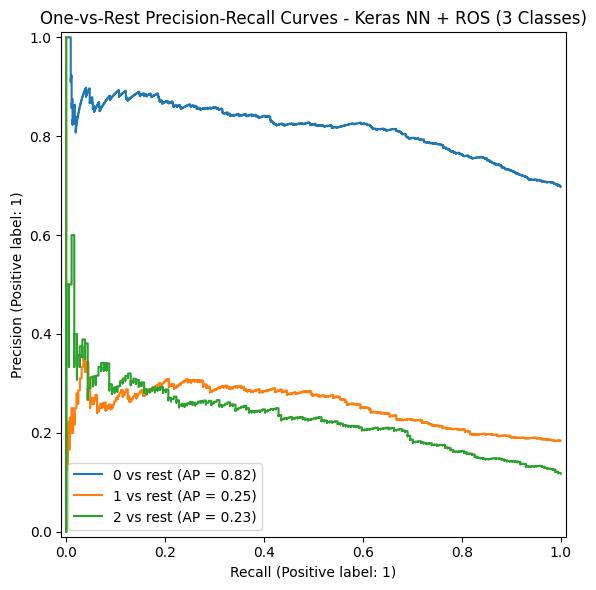


Classification report - Keras NN + ROS (3 Classes)


,precision,recall,f1-score,support
0,0.730655,0.896804,0.805248,1095.000000
1,0.283582,0.065744,0.106742,289.000000
2,0.273885,0.233696,0.252199,184.000000
accuracy,0.665816,0.665816,0.665816,0.665816
macro avg,0.429374,0.398748,0.388063,1568.000000
weighted avg,0.594654,0.665816,0.611607,1568.000000


In [51]:

# =========================================================================
# 5. VALUTAZIONE FINALE SUL TEST SET ORIGINALE (A 3 CLASSI)
# =========================================================================
print("\nFinal Evaluation on Test Set...")

y_score_keras = model_ros.predict(X_test)
y_pred_keras = np.argmax(y_score_keras, axis=1)

# Chiamata alla tua funzione universale per vedere la nuova matrice 3x3
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Keras NN + ROS (3 Classes)",
    normalize_cm="true"
)

Hyperparamters' tuning

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# =========================================================================
# 1. FORZIAMO IL PASSAGGIO A 3 CLASSI (Partendo dal dataset pulito originale)
# =========================================================================
# Assicuriamoci che y_clean contenga solo i valori 0, 1, 2
# Se i tuoi vecchi tag erano 0, 1, 2, 3 -> uniamo il 3 nel 2
y_clean_3classes = y.replace({3: 2}) 

print("Verifica distribuzione finale (Devono esserci SOLO tre numeri: 0, 1, 2):")
print(Counter(y_clean_3classes))

# =========================================================================
# 2. RIGENERAZIONE SPLIT (Train/Test e Train/Validation)
# =========================================================================
# Ricreiamo il Test Set a 3 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# Ricreiamo il Validation Set a 3 classi (quello pulito per il sintonizzatore)
X_tr_raw, X_val, y_tr_raw, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# =========================================================================
# 3. APPLICAZIONE ROS SUI NUOVI DATI ALLINEATI
# =========================================================================
ros = RandomOverSampler(random_state=42)
X_tr_ros, y_tr_ros = ros.fit_resample(X_tr_raw, y_tr_raw)

print("\nControllo finale prima del Tuner:")
print(f" -> Label unici nel Train ROS: {np.unique(y_tr_ros)} (Deve essere [0 1 2])")
print(f" -> Label unici nel Validation: {np.unique(y_val)} (Deve essere [0 1 2])")

Verifica distribuzione finale (Devono esserci SOLO tre numeri: 0, 1, 2):
Counter({0: 5476, 1: 1444, 2: 919})

Controllo finale prima del Tuner:
 -> Label unici nel Train ROS: [0 1 2] (Deve essere [0 1 2])
 -> Label unici nel Validation: [0 1 2] (Deve essere [0 1 2])


In [ ]:
import keras
from keras import layers
from keras.regularizers import l2
import keras_tuner as kt # keras tuner per l'ottimizzazione automatica degli iperparametri
import numpy as np

# =========================================================================
# 1. DEFINIZIONE DELLA FUNZIONE COSTRUTTRICE (Modello Dinamico)
# =========================================================================
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Scegliamo dinamicamente il NUMERO DI HIDDEN LAYER (da 1 a 3)
    num_layers = hp.Int('num_layers', min_value=1, max_value=3)
    
    for i in range(num_layers):
        # Scegliamo dinamicamente il NUMERO DI NODI per questo specifico strato
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        # Scegliamo la funzione di attivazione per questo strato
        activation = hp.Choice(f'activation_{i}', values=['relu', 'tanh'])
        
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=l2(0.001)))
        model.add(layers.BatchNormalization())
        
        # Scegliamo il tasso di Dropout dinamico per ogni strato
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
        model.add(layers.Dropout(dropout_rate))
    
    # Output Layer fisso (3 classi con Softmax)
    model.add(layers.Dense(3, activation='softmax'))
    
    # Scegliamo il Learning Rate ottimale
    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================================================================
# 2. INIZIALIZZAZIONE DEL TUNER (L'equivalente di RandomizedSearchCV)
# =========================================================================
# Cercheremo la combinazione che MINIMIZZA la validation loss sul set reale
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_loss', 
    max_trials=50,            # Numero di combinazioni casuali da testare (puoi alzarlo se hai tempo)
    executions_per_trial=1,   # Quante volte addestrare ogni modello per mediare i risultati
    #directory='keras_tuning', # Directory per salvare i risultati del tuning
    #project_name='mlp_optimization', # Nome del progetto
    #overwrite=True
)

# Visualizziamo lo spazio degli iperparametri definiti
tuner.search_space_summary()

# =========================================================================
# 3. AVVIO DELLA RICERCA AUTOMATICA
# =========================================================================
print("\nStarting Hyperparameter Search...")
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuner.search(
    X_tr_ros, y_tr_ros,                # Addestramento sul train oversamplato
    validation_data=(X_val, y_val),    # Validazione sul set reale sbilanciato
    epochs=100,                         # Epoche massime per ogni tentativo
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
# 1. Mostra il riassunto dei migliori risultati trovati
tuner.results_summary(num_trials=1)

# 2. Estraiamo il modello migliore già addestrato
best_model = tuner.get_best_models(num_models=1)[0]

# 3. Valutazione finale sul Test Set Reale
print("\nEvaluating Best Model on Test Set...")
y_score_keras = best_model.predict(X_test)
y_pred_keras = np.argmax(y_score_keras, axis=1)

# Chiamata alla tua funzione universale
results, report_df = evaluate_predictions(
    y_test=y_test,
    y_pred=y_pred_keras,
    y_score=y_score_keras,
    model_name="Optimized Keras NN (RandomSearch)",
    normalize_cm="true"
)